# Sub-Neptune Tidal Heating: Gas Envelope vs Rocky Core

This notebook explores how tidal dissipation is distributed through a rocky core and a gas-rich envelope in short-period sub-Neptunes using TidalPy's multilayer radial solver. The rocky interior uses an Andrade rheology, while the envelope is treated as a compressible dynamic liquid with a Newton rheology.

The main products are:
- A contour map of $\log_{10}(P_{\mathrm{tidal}} / P_{\mathrm{solar,abs}})$ as a function of planet radius and core-radius fraction, with benchmark radii marked as vertical guides.
- A second contour map of the same solar-normalized tidal power ratio with planet radius and orbital period as the axes, holding the core-radius fraction fixed at a literature-motivated value and highlighting JWST-observed or planned targets in green.
- Radial heating profiles for the maximum- and minimum-ratio worlds from each contour map, annotated with both the full tidal power and the absorbed solar reference power, and compared against cases with core dynamics disabled and with the static Kamata-style assumption enabled.

## Modeling Choices

This notebook uses a deliberately simple but TidalPy-native interior construction: multiple homogeneous sublayers with different densities, bulk moduli, and viscosities. That satisfies the requirement to pre-build a stratified rocky core plus gas envelope before passing the interior to TidalPy, while avoiding the unfinished layered gas-world builder in the current codebase.

Literature context used here:
- Lopez and Fortney (2014) show that even modest H/He envelope mass fractions strongly inflate sub-Neptune radii, so the envelope can occupy a large radial fraction even when it is a small fraction of the mass.
- Nixon et al. (2024) infer that GJ 1214 b requires a non-negligible envelope mass fraction, reinforcing the picture of a compact dense interior plus a radially extended envelope.

For the radius-period contour, I adopt a fixed core-radius fraction of `0.55` rather than `0.8`. That keeps the dense interior important while leaving a broad outer envelope, which is more consistent with the radially extended structures usually inferred for gas-rich sub-Neptunes and sub-Saturns. The radius-core sweep explicitly spans a wider range around that reference value.

The observed systems below are used only to anchor representative masses, radii, periods, and host-star masses. The fiducial eccentricity for the heating experiments is set to `0.03` so that the tidal response is visible; several observed systems have smaller best-fit eccentricities and would correspondingly produce lower absolute heating.

In [1]:
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import trapezoid

from TidalPy.RadialSolver import build_rs_input_homogeneous_layers, radial_solver
from TidalPy.rheology import Andrade, Elastic, Maxwell, Newton
from TidalPy.tides import calculate_volumetric_heating
from TidalPy.tides.modes.multilayer_modes import collapse_multilayer_modes
from TidalPy.tides.multilayer.stress_strain import calculate_strain_stress
from TidalPy.tides.potential import tidal_potential_simple
from TidalPy.utilities.conversions import days2rads, orbital_motion2semi_a
from TidalPy.utilities.spherical_helper.volume import calculate_voxel_volumes

np.seterr(divide='ignore', invalid='ignore')

EARTH_RADIUS = 6.371e6
EARTH_MASS = 5.9722e24
SOLAR_MASS = 1.98847e30

USE_BULK_DISSIPATION = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 15

COMMON_SOLVER_KWARGS = dict(
    degree_l=2,
    solve_for=('tidal',),
    starting_radius=0.0,
    use_kamata=False,
    integration_method='DOP853',
    integration_rtol=1.0e-6,
    integration_atol=1.0e-8,
    scale_rtols_bylayer_type=False,
    max_num_steps=500_000,
    expected_size=1_000,
    max_ram_MB=500,
    max_step=0.0,
    nondimensionalize=True,
    use_prop_matrix=False,
    verbose=False,
    warnings=False,
    raise_on_fail=False,
    perform_checks=True,
)

ANGULAR_GRID = dict(n_longitude=10, n_colatitude=8, n_time=10)

In [2]:
PLANET_MARKER_STYLES = {
    'sub-neptune': {
        'marker': '^',
        'size': 56,
        'legend_label': 'Sub-Neptune / Neptune',
    },
    'sub-saturn': {
        'marker': 'D',
        'size': 52,
        'legend_label': 'Sub-Saturn',
    },
}

OBSERVED_SUB_NEPTUNES = {
    'GJ 1214 b': {
        'planet_radius_re': 2.733,
        'planet_mass_me': 8.41,
        'period_days': 1.580404531,
        'eccentricity': 0.0062,
        'host_mass_msun': 0.182,
        'planet_class': 'sub-neptune',
    },
    'TOI-270 d': {
        'planet_radius_re': 2.133,
        'planet_mass_me': 4.20,
        'period_days': 11.379573,
        'eccentricity': 0.0066,
        'host_mass_msun': 0.386,
        'planet_class': 'sub-neptune',
    },
    'HD 97658 b': {
        'planet_radius_re': 2.247,
        'planet_mass_me': 7.81,
        'period_days': 9.49073,
        'eccentricity': 0.03,
        'host_mass_msun': 0.773,
        'planet_class': 'sub-neptune',
    },
    'TOI-763 b': {
        'planet_radius_re': 2.28,
        'planet_mass_me': 9.79,
        'period_days': 5.6057,
        'eccentricity': 0.04,
        'host_mass_msun': 0.91,
        'planet_class': 'sub-neptune',
    },
    'TOI-181 b': {
        'planet_radius_re': 6.96,
        'planet_mass_me': 16.4,
        'period_days': 4.53,
        'eccentricity': 0.0,
        'host_mass_msun': 0.82,
        'planet_class': 'sub-saturn',
    },
    'WASP-166 b': {
        'planet_radius_re': 7.06,
        'planet_mass_me': 32.1,
        'period_days': 5.44354,
        'eccentricity': 0.0,
        'host_mass_msun': 1.19,
        'planet_class': 'sub-saturn',
    },
    'HAT-P-26 b': {
        'planet_radius_re': 6.33,
        'planet_mass_me': 22.25,
        'period_days': 4.234516,
        'eccentricity': 0.124,
        'host_mass_msun': 0.816,
        'planet_class': 'sub-saturn',
    },
    'Kepler-9 b': {
        'planet_radius_re': 9.44,
        'planet_mass_me': 43.5,
        'period_days': 19.24,
        'eccentricity': 0.0,
        'host_mass_msun': 1.07,
        'planet_class': 'sub-saturn',
    },
    'K2-24 b': {
        'planet_radius_re': 5.58,
        'planet_mass_me': 22.34,
        'period_days': 20.8851,
        'eccentricity': 0.06,
        'host_mass_msun': 1.12,
        'planet_class': 'sub-saturn',
    },
    'HD 89345 b': {
        'planet_radius_re': 6.86,
        'planet_mass_me': 35.7,
        'period_days': 11.814,
        'eccentricity': 0.2,
        'host_mass_msun': 1.12,
        'planet_class': 'sub-saturn',
    },
    'TOI-1822 b': {
        'planet_radius_re': 14.57,
        'planet_mass_me': np.nan,
        'period_days': 9.61,
        'eccentricity': 0.0,
        'host_mass_msun': 1.15,
        'planet_class': 'sub-saturn',
    },
}

for name, values in OBSERVED_SUB_NEPTUNES.items():
    print(
        f"{name:12s}  class={values['planet_class']:11s}  "
        f"R={values['planet_radius_re']:.3f} R_earth  "
        f"M={values['planet_mass_me']:.2f} M_earth  "
        f"P={values['period_days']:.3f} d  "
        f"e={values['eccentricity']:.4f}  "
        f"M_star={values['host_mass_msun']:.3f} M_sun"
    )

FIDUCIAL_SYSTEM = {**OBSERVED_SUB_NEPTUNES['GJ 1214 b']}
FIDUCIAL_SYSTEM['eccentricity'] = 0.03
FIDUCIAL_LABEL = 'GJ 1214 b-inspired fiducial case'

GJ 1214 b     class=sub-neptune  R=2.733 R_earth  M=8.41 M_earth  P=1.580 d  e=0.0062  M_star=0.182 M_sun
TOI-270 d     class=sub-neptune  R=2.133 R_earth  M=4.20 M_earth  P=11.380 d  e=0.0066  M_star=0.386 M_sun
HD 97658 b    class=sub-neptune  R=2.247 R_earth  M=7.81 M_earth  P=9.491 d  e=0.0300  M_star=0.773 M_sun
TOI-763 b     class=sub-neptune  R=2.280 R_earth  M=9.79 M_earth  P=5.606 d  e=0.0400  M_star=0.910 M_sun
TOI-181 b     class=sub-saturn   R=6.960 R_earth  M=16.40 M_earth  P=4.530 d  e=0.0000  M_star=0.820 M_sun
WASP-166 b    class=sub-saturn   R=7.060 R_earth  M=32.10 M_earth  P=5.444 d  e=0.0000  M_star=1.190 M_sun
HAT-P-26 b    class=sub-saturn   R=6.330 R_earth  M=22.25 M_earth  P=4.235 d  e=0.1240  M_star=0.816 M_sun
Kepler-9 b    class=sub-saturn   R=9.440 R_earth  M=43.50 M_earth  P=19.240 d  e=0.0000  M_star=1.070 M_sun
K2-24 b       class=sub-saturn   R=5.580 R_earth  M=22.34 M_earth  P=20.885 d  e=0.0600  M_star=1.120 M_sun
HD 89345 b    class=sub-saturn   R=6.8

In [3]:
def estimate_subneptune_mass_me(radius_re):
    """A compact empirical mass-radius scaling for gas-rich planets in Earth units."""

    return 2.69 * radius_re**0.93


def collapse_radial_profile(radius_re, shell_avg_heating_wm3, decimals=10):
    radius_re = np.asarray(radius_re, dtype=np.float64)
    shell_avg_heating_wm3 = np.asarray(shell_avg_heating_wm3, dtype=np.float64)

    valid = np.isfinite(radius_re) & np.isfinite(shell_avg_heating_wm3)
    valid &= radius_re > 0.0

    radius_re = radius_re[valid]
    shell_avg_heating_wm3 = shell_avg_heating_wm3[valid]

    if radius_re.size == 0:
        return radius_re, shell_avg_heating_wm3

    rounded_radius = np.round(radius_re, decimals=decimals)
    unique_radius, inverse = np.unique(rounded_radius, return_inverse=True)

    collapsed_radius = np.zeros(unique_radius.size, dtype=np.float64)
    collapsed_heating = np.zeros(unique_radius.size, dtype=np.float64)
    counts = np.zeros(unique_radius.size, dtype=np.int64)

    np.add.at(collapsed_radius, inverse, radius_re)
    np.add.at(collapsed_heating, inverse, shell_avg_heating_wm3)
    np.add.at(counts, inverse, 1)

    collapsed_radius /= counts
    collapsed_heating /= counts

    return collapsed_radius, np.maximum(collapsed_heating, np.finfo(np.float64).tiny)


def build_material_property_tuples(core_layers, gas_layers):
    total_layers = core_layers + gas_layers

    density_tuple = tuple(
        np.concatenate([
            np.linspace(7_800.0, 4_600.0, core_layers),
            np.geomspace(1_200.0, 60.0, gas_layers),
        ])
    )
    static_bulk_modulus_tuple = tuple(
        np.concatenate([
            np.linspace(260.0e9, 160.0e9, core_layers),
            np.geomspace(12.0e9, 3.0e8, gas_layers),
        ])
    )
    static_shear_modulus_tuple = tuple(
        np.concatenate([
            np.linspace(90.0e9, 35.0e9, core_layers),
            np.zeros(gas_layers),
        ])
    )
    shear_viscosity_tuple = tuple(
        np.concatenate([
            np.geomspace(1.0e22, 1.0e19, core_layers),
            np.geomspace(1.0e6, 1.0e4, gas_layers),
        ])
    )

    if USE_BULK_DISSIPATION:
        bulk_viscosity_tuple = tuple(
            np.concatenate([
                np.geomspace(1.0e24, 1.0e21, core_layers),
                np.geomspace(1.0e10, 1.0e8, gas_layers),
            ])
        )
        bulk_rheology_model_tuple = tuple([Maxwell() for _ in range(total_layers)])
    else:
        bulk_viscosity_tuple = tuple(np.full(total_layers, 1.0e30))
        bulk_rheology_model_tuple = tuple([Elastic() for _ in range(total_layers)])

    layer_type_tuple = tuple(['solid'] * core_layers + ['liquid'] * gas_layers)
    layer_is_static_tuple = tuple([False] * core_layers + [True] * gas_layers)
    layer_is_incompressible_tuple = tuple([False] * total_layers)
    shear_rheology_model_tuple = tuple(
        [Andrade() for _ in range(core_layers)] + [Newton() for _ in range(gas_layers)]
    )

    return dict(
        density_tuple=density_tuple,
        static_bulk_modulus_tuple=static_bulk_modulus_tuple,
        static_shear_modulus_tuple=static_shear_modulus_tuple,
        bulk_viscosity_tuple=bulk_viscosity_tuple,
        shear_viscosity_tuple=shear_viscosity_tuple,
        layer_type_tuple=layer_type_tuple,
        layer_is_static_tuple=layer_is_static_tuple,
        layer_is_incompressible_tuple=layer_is_incompressible_tuple,
        shear_rheology_model_tuple=shear_rheology_model_tuple,
        bulk_rheology_model_tuple=bulk_rheology_model_tuple,
    )


def build_layered_subneptune_inputs(
    planet_radius_re,
    core_radius_fraction,
    period_days,
    core_layers=1,
    gas_layers=1,
    slice_per_layer=50,
):
    planet_radius = planet_radius_re * EARTH_RADIUS
    forcing_frequency = days2rads(period_days)

    core_radius_fracs = np.linspace(
        core_radius_fraction / core_layers,
        core_radius_fraction,
        core_layers,
    )
    gas_radius_fracs = np.linspace(
        core_radius_fraction + (1.0 - core_radius_fraction) / gas_layers,
        1.0,
        gas_layers,
    )
    radius_fraction_tuple = tuple(np.concatenate([core_radius_fracs, gas_radius_fracs]))

    material_setup = build_material_property_tuples(core_layers=core_layers, gas_layers=gas_layers)

    rs_inputs = build_rs_input_homogeneous_layers(
        planet_radius,
        forcing_frequency,
        material_setup['density_tuple'],
        material_setup['static_bulk_modulus_tuple'],
        material_setup['static_shear_modulus_tuple'],
        material_setup['bulk_viscosity_tuple'],
        material_setup['shear_viscosity_tuple'],
        material_setup['layer_type_tuple'],
        material_setup['layer_is_static_tuple'],
        material_setup['layer_is_incompressible_tuple'],
        material_setup['shear_rheology_model_tuple'],
        material_setup['bulk_rheology_model_tuple'],
        radius_fraction_tuple=radius_fraction_tuple,
        slice_per_layer=slice_per_layer,
        perform_checks=True,
    )

    material_setup['radius_fraction_tuple'] = radius_fraction_tuple

    return rs_inputs, planet_radius, forcing_frequency, core_radius_fraction * planet_radius, material_setup


def build_helper_comparison_planet(
    planet_radius,
    host_mass,
    period_days,
    eccentricity,
    radius_fraction_tuple,
    material_setup,
):
    from structures import CoreLayer, GasLayer, Planet

    layers = []
    upper_radii = np.asarray(radius_fraction_tuple, dtype=np.float64) * planet_radius
    total_layers = len(radius_fraction_tuple)

    for layer_index in range(total_layers):
        layer_radius = float(upper_radii[layer_index])
        base_kwargs = dict(
            radius=layer_radius,
            name=f'Layer {layer_index + 1}',
            density=float(material_setup['density_tuple'][layer_index]),
            shear_modulus=float(material_setup['static_shear_modulus_tuple'][layer_index]),
            bulk_modulus=float(material_setup['static_bulk_modulus_tuple'][layer_index]),
            shear_viscosity=float(material_setup['shear_viscosity_tuple'][layer_index]),
            bulk_viscosity=float(material_setup['bulk_viscosity_tuple'][layer_index]),
        )

        if layer_index < sum(layer_type == 'solid' for layer_type in material_setup['layer_type_tuple']):
            layer = CoreLayer(**base_kwargs)
        else:
            layer = GasLayer(**base_kwargs)

        layer.is_static = material_setup['layer_is_static_tuple'][layer_index]
        layer.is_incompressible = material_setup['layer_is_incompressible_tuple'][layer_index]
        layer.shear_rheology_model = material_setup['shear_rheology_model_tuple'][layer_index]
        layer.bulk_rheology_model = material_setup['bulk_rheology_model_tuple'][layer_index]
        layers.append(layer)

    return Planet(
        name='Helper comparison planet',
        radius=planet_radius,
        layers=layers,
        host_mass=host_mass,
        eccentricity=eccentricity,
        obliquity=0.0,
        orbital_period=period_days,
        spin_period=period_days,
    )


@lru_cache(maxsize=256)
def solve_case(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
    label='case',
):
    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, _ = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
    )

    solution = radial_solver(*rs_inputs, **COMMON_SOLVER_KWARGS)
    if not solution.success:
        return {
            'success': False,
            'label': label,
            'planet_radius_re': planet_radius_re,
            'period_days': period_days,
            'core_radius_fraction': core_radius_fraction,
            'message': solution.message,
        }

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )

    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        semi_major_axis,
    )

    potential_components = potential_by_mode['n']
    strains, stresses = calculate_strain_stress(
        *potential_components,
        solution.result,
        longitude,
        colatitude,
        time_domain,
        solution.radius_array,
        rs_inputs.complex_shear_modulus_array,
        rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )

    volumetric_heating_orbit_avg = trapezoid(
        calculate_volumetric_heating(stresses, strains),
        time_domain,
        axis=-1,
    ) / orbital_period
    volumetric_heating_orbit_avg = np.nan_to_num(
        volumetric_heating_orbit_avg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)
    heating_orbit_avg = volumetric_heating_orbit_avg * voxel_volume

    core_mask = solution.radius_array <= core_radius
    core_heating_w = np.sum(heating_orbit_avg[core_mask])
    gas_heating_w = np.sum(heating_orbit_avg[~core_mask])
    total_heating_w = np.sum(heating_orbit_avg)

    shell_power_w = np.sum(heating_orbit_avg, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))
    shell_avg_heating_wm3 = np.divide(
        shell_power_w,
        shell_volume,
        out=np.zeros_like(shell_power_w),
        where=shell_volume > 0,
    )
    profile_radius_re, profile_heating_wm3 = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        shell_avg_heating_wm3,
    )

    tiny = np.finfo(np.float64).tiny
    ratio_core_to_gas = core_heating_w / max(gas_heating_w, tiny)

    return {
        'success': True,
        'label': label,
        'planet_radius_re': planet_radius_re,
        'planet_mass_me': planet_mass_me,
        'period_days': period_days,
        'eccentricity': eccentricity,
        'host_mass_msun': host_mass_msun,
        'core_radius_fraction': core_radius_fraction,
        'core_radius_re': core_radius / EARTH_RADIUS,
        'q_eff_abs': float(abs(solution.Q)),
        'love_k_abs': float(abs(solution.k)),
        'total_heating_w': float(total_heating_w),
        'core_heating_w': float(core_heting_w) if False else float(core_heating_w),
        'gas_heating_w': float(gas_heating_w),
        'ratio_core_to_gas': float(ratio_core_to_gas),
        'log10_ratio_core_to_gas': float(np.log10(max(ratio_core_to_gas, tiny))),
        'radius_re': solution.radius_array / EARTH_RADIUS,
        'shell_avg_heating_wm3': shell_avg_heating_wm3,
        'profile_radius_re': profile_radius_re,
        'profile_heating_wm3': profile_heating_wm3,
    }


def compare_heating_methods(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
):
    from helpers import build_rs_inputs as build_demo_rs_inputs, cmm_optional_args as demo_cmm_optional_args

    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, material_setup = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
        slice_per_layer=50,
    )
    solution = radial_solver(*rs_inputs, **COMMON_SOLVER_KWARGS)
    if not solution.success:
        raise RuntimeError(solution.message)

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )
    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)

    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        semi_major_axis,
    )
    strains_modern, stresses_modern = calculate_strain_stress(
        *potential_by_mode['n'],
        solution.result,
        longitude,
        colatitude,
        time_domain,
        solution.radius_array,
        rs_inputs.complex_shear_modulus_array,
        rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )
    volumetric_heating_modern = trapezoid(
        calculate_volumetric_heating(stresses_modern, strains_modern),
        time_domain,
        axis=-1,
    ) / orbital_period
    volumetric_heating_modern = np.nan_to_num(
        volumetric_heating_modern,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    heating_modern = volumetric_heating_modern * voxel_volume

    comparison_planet = build_helper_comparison_planet(
        planet_radius=planet_radius,
        host_mass=host_mass,
        period_days=period_days,
        eccentricity=eccentricity,
        radius_fraction_tuple=material_setup['radius_fraction_tuple'],
        material_setup=material_setup,
    )
    helper_rs_inputs, helper_cmm_inputs, _ = build_demo_rs_inputs(comparison_planet)
    helper_optional_args = dict(demo_cmm_optional_args)
    helper_optional_args['use_simple_potential'] = True
    heating_legacy, *_ = collapse_multilayer_modes(*helper_cmm_inputs, **helper_optional_args)

    shell_power_modern = np.sum(heating_modern, axis=(1, 2))
    shell_power_legacy = np.sum(heating_legacy, axis=(1, 2))
    shell_volume_modern = np.sum(voxel_volume, axis=(1, 2))
    helper_voxel_volume = helper_cmm_inputs[18]
    shell_volume_legacy = np.sum(helper_voxel_volume, axis=(1, 2))

    profile_radius_re, profile_modern = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        np.divide(shell_power_modern, shell_volume_modern, out=np.zeros_like(shell_power_modern), where=shell_volume_modern > 0),
    )
    _, profile_legacy = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_legacy, shell_volume_legacy, out=np.zeros_like(shell_power_legacy), where=shell_volume_legacy > 0),
    )

    total_modern = float(np.sum(heating_modern))
    total_legacy = float(np.sum(heating_legacy))
    relative_difference = abs(total_modern - total_legacy) / max(abs(total_legacy), np.finfo(np.float64).tiny)

    return {
        'total_heating_modern_w': total_modern,
        'total_heating_legacy_w': total_legacy,
        'relative_difference': float(relative_difference),
        'profile_radius_re': profile_radius_re,
        'profile_modern_wm3': profile_modern,
        'profile_legacy_wm3': profile_legacy,
        'core_radius_re': core_radius / EARTH_RADIUS,
    }


def evaluate_ratio_grid(
    x_values,
    y_values,
    case_builder,
):
    ratio_grid = np.full((len(y_values), len(x_values)), np.nan, dtype=np.float64)
    q_grid = np.full_like(ratio_grid, np.nan)
    total_heating_grid = np.full_like(ratio_grid, np.nan)
    case_lookup = {}

    for y_index, y_value in enumerate(y_values):
        for x_index, x_value in enumerate(x_values):
            case = case_builder(x_value, y_value)
            case_lookup[(y_index, x_index)] = case
            if case['success']:
                ratio_grid[y_index, x_index] = case['log10_ratio_core_to_gas']
                q_grid[y_index, x_index] = case['q_eff_abs']
                total_heating_grid[y_index, x_index] = case['total_heating_w']

    return ratio_grid, q_grid, total_heating_grid, case_lookup


def find_grid_extrema(ratio_grid):
    finite = np.isfinite(ratio_grid)
    if not np.any(finite):
        raise RuntimeError('No successful models were found in the requested grid.')

    masked = np.where(finite, ratio_grid, np.nan)
    max_index = np.unravel_index(np.nanargmax(masked), masked.shape)
    min_index = np.unravel_index(np.nanargmin(masked), masked.shape)
    return max_index, min_index


def plot_ratio_contour(x_values, y_values, ratio_grid, xlabel, ylabel, title):
    x_mesh, y_mesh = np.meshgrid(x_values, y_values)
    finite = np.isfinite(ratio_grid)
    vmin = np.nanmin(ratio_grid[finite])
    vmax = np.nanmax(ratio_grid[finite])
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0

    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    contour = ax.contourf(
        x_mesh,
        y_mesh,
        ratio_grid,
        levels=np.linspace(vmin, vmax, 16),
        cmap='coolwarm',
    )
    fig.colorbar(contour, ax=ax, label=r'$\log_{10}(H_{\mathrm{core}} / H_{\mathrm{gas}})$')
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    return fig, ax


def add_extrema_markers(ax, x_values, y_values, ratio_grid):
    max_index, min_index = find_grid_extrema(ratio_grid)
    max_point = (x_values[max_index[1]], y_values[max_index[0]])
    min_point = (x_values[min_index[1]], y_values[min_index[0]])

    ax.plot(*max_point, marker='o', markersize=9, markeredgecolor='black', color='gold', label='Maximum ratio')
    ax.plot(*min_point, marker='X', markersize=9, markeredgecolor='black', color='black', label='Minimum ratio')
    ax.legend(loc='best')

    return max_index, min_index


def add_reference_period_markers(ax, systems, x_bounds=None, y_bounds=None):
    seen_classes = set()

    for name, values in systems.items():
        if x_bounds is not None and not (x_bounds[0] <= values['planet_radius_re'] <= x_bounds[1]):
            continue
        if y_bounds is not None and not (y_bounds[0] <= values['period_days'] <= y_bounds[1]):
            continue

        style = PLANET_MARKER_STYLES[values['planet_class']]
        label = style['legend_label'] if values['planet_class'] not in seen_classes else None
        seen_classes.add(values['planet_class'])

        ax.scatter(
            values['planet_radius_re'],
            values['period_days'],
            s=style['size'],
            marker=style['marker'],
            facecolor='white',
            edgecolor='black',
            linewidth=0.9,
            zorder=5,
            label=label,
        )
        ax.annotate(
            name,
            (values['planet_radius_re'], values['period_days']),
            xytext=(6, 5),
            textcoords='offset points',
            fontsize=12,
            color='black',
        )


def plot_extreme_radial_profiles(cases, title):
    fig, axes = plt.subplots(ncols=len(cases), figsize=(6.2 * len(cases), 4.8), sharey=True)
    fig.suptitle(title)

    if len(cases) == 1:
        axes = [axes]

    for axis, case in zip(axes, cases):
        axis.semilogx(
            case['profile_heating_wm3'],
            case['profile_radius_re'],
            color='tab:red',
            linewidth=2.0,
        )
        axis.axhline(case['core_radius_re'], color='black', linestyle='--', linewidth=1.2)
        axis.axhspan(case['core_radius_re'], case['planet_radius_re'], color='tab:blue', alpha=0.12)
        axis.set(
            xlabel=r'Shell-averaged heating [W m$^{-3}$]',
            title=case['label'],
            ylim=(0.0, case['planet_radius_re']),
        )
        axis.grid(alpha=0.25, which='both', axis='x')
        axis.text(
            0.03,
            0.97,
            f"P_tidal = {case['total_heating_w']:.3e} W\n|Q| = {case['q_eff_abs']:.2f}\n"
            f"log10(core/gas) = {case['log10_ratio_core_to_gas']:.2f}",
            transform=axis.transAxes,
            va='top',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.7'),
        )

    axes[0].set_ylabel('Radius [R_earth]')
    fig.tight_layout()
    return fig, axes

In [4]:
def stable_heating_ratio(core_heating_w, gas_heating_w):
    tiny = np.finfo(np.float64).tiny
    log10_ratio = np.log10(max(core_heating_w, tiny)) - np.log10(max(gas_heating_w, tiny))
    ratio_core_to_gas = 10.0 ** np.clip(log10_ratio, -300.0, 300.0)
    return float(ratio_core_to_gas), float(log10_ratio)


@lru_cache(maxsize=256)
def solve_case(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
    label='case',
):
    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, _ = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
    )

    solution = radial_solver(*rs_inputs, **COMMON_SOLVER_KWARGS)
    if not solution.success:
        return {
            'success': False,
            'label': label,
            'planet_radius_re': planet_radius_re,
            'period_days': period_days,
            'core_radius_fraction': core_radius_fraction,
            'message': solution.message,
        }

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )

    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        semi_major_axis,
    )

    strains, stresses = calculate_strain_stress(
        *potential_by_mode['n'],
        solution.result,
        longitude,
        colatitude,
        time_domain,
        solution.radius_array,
        rs_inputs.complex_shear_modulus_array,
        rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )

    volumetric_heating_orbit_avg = trapezoid(
        calculate_volumetric_heating(stresses, strains),
        time_domain,
        axis=-1,
    ) / orbital_period
    volumetric_heating_orbit_avg = np.nan_to_num(
        volumetric_heating_orbit_avg,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)
    heating_orbit_avg = volumetric_heating_orbit_avg * voxel_volume

    core_mask = solution.radius_array <= core_radius
    core_heating_w = float(np.sum(heating_orbit_avg[core_mask]))
    gas_heating_w = float(np.sum(heating_orbit_avg[~core_mask]))
    total_heating_w = float(np.sum(heating_orbit_avg))

    shell_power_w = np.sum(heating_orbit_avg, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))
    shell_avg_heating_wm3 = np.divide(
        shell_power_w,
        shell_volume,
        out=np.zeros_like(shell_power_w),
        where=shell_volume > 0,
    )
    profile_radius_re, profile_heating_wm3 = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        shell_avg_heating_wm3,
    )

    ratio_core_to_gas, log10_ratio_core_to_gas = stable_heating_ratio(core_heating_w, gas_heating_w)

    return {
        'success': True,
        'label': label,
        'planet_radius_re': planet_radius_re,
        'planet_mass_me': planet_mass_me,
        'period_days': period_days,
        'eccentricity': eccentricity,
        'host_mass_msun': host_mass_msun,
        'core_radius_fraction': core_radius_fraction,
        'core_radius_re': core_radius / EARTH_RADIUS,
        'q_eff_abs': float(abs(solution.Q)),
        'love_k_abs': float(abs(solution.k)),
        'total_heating_w': total_heating_w,
        'core_heating_w': core_heating_w,
        'gas_heating_w': gas_heating_w,
        'ratio_core_to_gas': ratio_core_to_gas,
        'log10_ratio_core_to_gas': log10_ratio_core_to_gas,
        'radius_re': solution.radius_array / EARTH_RADIUS,
        'shell_avg_heating_wm3': shell_avg_heating_wm3,
        'profile_radius_re': profile_radius_re,
        'profile_heating_wm3': profile_heating_wm3,
    }


def compare_heating_methods(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
):
    from helpers import build_rs_inputs as build_demo_rs_inputs, cmm_optional_args as demo_cmm_optional_args

    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, material_setup = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
        slice_per_layer=50,
    )
    solution = radial_solver(*rs_inputs, **COMMON_SOLVER_KWARGS)
    if not solution.success:
        raise RuntimeError(solution.message)

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )
    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)

    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        semi_major_axis,
    )
    strains_modern, stresses_modern = calculate_strain_stress(
        *potential_by_mode['n'],
        solution.result,
        longitude,
        colatitude,
        time_domain,
        solution.radius_array,
        rs_inputs.complex_shear_modulus_array,
        rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )
    volumetric_heating_modern = trapezoid(
        calculate_volumetric_heating(stresses_modern, strains_modern),
        time_domain,
        axis=-1,
    ) / orbital_period
    volumetric_heating_modern = np.nan_to_num(
        volumetric_heating_modern,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    heating_modern = np.nan_to_num(volumetric_heating_modern * voxel_volume, nan=0.0, posinf=0.0, neginf=0.0)

    comparison_planet = build_helper_comparison_planet(
        planet_radius=planet_radius,
        host_mass=host_mass,
        period_days=period_days,
        eccentricity=eccentricity,
        radius_fraction_tuple=material_setup['radius_fraction_tuple'],
        material_setup=material_setup,
    )
    helper_rs_inputs, helper_cmm_inputs, _ = build_demo_rs_inputs(comparison_planet)
    helper_optional_args = dict(demo_cmm_optional_args)
    helper_optional_args['use_simple_potential'] = True
    heating_legacy, *_ = collapse_multilayer_modes(*helper_cmm_inputs, **helper_optional_args)
    heating_legacy = np.nan_to_num(heating_legacy, nan=0.0, posinf=0.0, neginf=0.0)

    shell_power_modern = np.sum(heating_modern, axis=(1, 2))
    shell_power_legacy = np.sum(heating_legacy, axis=(1, 2))
    shell_volume_modern = np.sum(voxel_volume, axis=(1, 2))
    helper_voxel_volume = helper_cmm_inputs[18]
    shell_volume_legacy = np.sum(helper_voxel_volume, axis=(1, 2))

    profile_radius_re, profile_modern = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        np.divide(shell_power_modern, shell_volume_modern, out=np.zeros_like(shell_power_modern), where=shell_volume_modern > 0),
    )
    _, profile_legacy = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_legacy, shell_volume_legacy, out=np.zeros_like(shell_power_legacy), where=shell_volume_legacy > 0),
    )

    total_modern = float(np.sum(heating_modern))
    total_legacy = float(np.sum(heating_legacy))
    relative_difference = abs(total_modern - total_legacy) / max(abs(total_legacy), np.finfo(np.float64).tiny)

    return {
        'total_heating_modern_w': total_modern,
        'total_heating_legacy_w': total_legacy,
        'relative_difference': float(relative_difference),
        'profile_radius_re': profile_radius_re,
        'profile_modern_wm3': profile_modern,
        'profile_legacy_wm3': profile_legacy,
        'core_radius_re': core_radius / EARTH_RADIUS,
    }

In [5]:
def compare_heating_methods(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
):
    from helpers import (
        build_rs_inputs as build_demo_rs_inputs,
        cmm_optional_args as demo_cmm_optional_args,
        rs_optional_args as demo_rs_optional_args,
    )

    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, material_setup = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
        slice_per_layer=50,
    )
    host_mass = host_mass_msun * SOLAR_MASS

    comparison_planet = build_helper_comparison_planet(
        planet_radius=planet_radius,
        host_mass=host_mass,
        period_days=period_days,
        eccentricity=eccentricity,
        radius_fraction_tuple=material_setup['radius_fraction_tuple'],
        material_setup=material_setup,
    )
    helper_rs_inputs, helper_cmm_inputs, helper_arrays = build_demo_rs_inputs(comparison_planet)
    helper_solution = radial_solver(*helper_rs_inputs, **demo_rs_optional_args)
    if not helper_solution.success:
        raise RuntimeError(helper_solution.message)

    colatitude, longitude, time_domain, _ = helper_arrays
    longitude_matrix = helper_cmm_inputs[15]
    colatitude_matrix = helper_cmm_inputs[16]
    time_matrix = helper_cmm_inputs[17]
    voxel_volume = helper_cmm_inputs[18]
    orbital_period = 2.0 * np.pi / forcing_frequency

    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        comparison_planet.semi_major_axis,
    )
    strains_modern, stresses_modern = calculate_strain_stress(
        *potential_by_mode['n'],
        helper_solution.result,
        longitude,
        colatitude,
        time_domain,
        helper_solution.radius_array,
        helper_rs_inputs.complex_shear_modulus_array,
        helper_rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )
    volumetric_heating_modern = trapezoid(
        calculate_volumetric_heating(stresses_modern, strains_modern),
        time_domain,
        axis=-1,
    ) / orbital_period
    volumetric_heating_modern = np.nan_to_num(
        volumetric_heating_modern,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )
    heating_modern = np.nan_to_num(volumetric_heating_modern * voxel_volume, nan=0.0, posinf=0.0, neginf=0.0)

    helper_optional_args = dict(demo_cmm_optional_args)
    helper_optional_args['use_simple_potential'] = True
    heating_legacy, *_ = collapse_multilayer_modes(*helper_cmm_inputs, **helper_optional_args)
    heating_legacy = np.nan_to_num(heating_legacy, nan=0.0, posinf=0.0, neginf=0.0)

    shell_power_modern = np.sum(heating_modern, axis=(1, 2))
    shell_power_legacy = np.sum(heating_legacy, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))

    profile_radius_re, profile_modern = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_modern, shell_volume, out=np.zeros_like(shell_power_modern), where=shell_volume > 0),
    )
    _, profile_legacy = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_legacy, shell_volume, out=np.zeros_like(shell_power_legacy), where=shell_volume > 0),
    )

    total_modern = float(np.sum(heating_modern))
    total_legacy = float(np.sum(heating_legacy))
    relative_difference = abs(total_modern - total_legacy) / max(abs(total_legacy), np.finfo(np.float64).tiny)

    return {
        'total_heating_modern_w': total_modern,
        'total_heating_legacy_w': total_legacy,
        'relative_difference': float(relative_difference),
        'profile_radius_re': profile_radius_re,
        'profile_modern_wm3': profile_modern,
        'profile_legacy_wm3': profile_legacy,
        'core_radius_re': core_radius / EARTH_RADIUS,
    }

In [6]:
def compute_orbit_averaged_heating(
    solution,
    rs_inputs,
    planet_radius,
    forcing_frequency,
    eccentricity,
    host_mass,
    semi_major_axis,
    longitude,
    colatitude,
    time_domain,
    longitude_matrix,
    colatitude_matrix,
    time_matrix,
):
    _, _, potential_by_mode = tidal_potential_simple(
        planet_radius,
        longitude_matrix,
        colatitude_matrix,
        time_matrix,
        forcing_frequency,
        eccentricity,
        host_mass,
        semi_major_axis,
    )

    strains, stresses = calculate_strain_stress(
        *potential_by_mode['n'],
        solution.result,
        longitude,
        colatitude,
        time_domain,
        solution.radius_array,
        rs_inputs.complex_shear_modulus_array,
        rs_inputs.complex_bulk_modulus_array,
        forcing_frequency,
        degree_l=2,
    )

    freq_half = forcing_frequency / 2.0
    stresses = stresses * freq_half
    strains = strains * freq_half

    volumetric_heating_orbit_avg = trapezoid(
        calculate_volumetric_heating(stresses, strains),
        time_domain,
        axis=-1,
    )
    return np.nan_to_num(volumetric_heating_orbit_avg, nan=0.0, posinf=0.0, neginf=0.0)


@lru_cache(maxsize=256)
def solve_case(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
    label='case',
):
    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, _ = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
    )

    solution = radial_solver(*rs_inputs, **COMMON_SOLVER_KWARGS)
    if not solution.success:
        return {
            'success': False,
            'label': label,
            'planet_radius_re': planet_radius_re,
            'period_days': period_days,
            'core_radius_fraction': core_radius_fraction,
            'message': solution.message,
        }

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )

    volumetric_heating_orbit_avg = compute_orbit_averaged_heating(
        solution=solution,
        rs_inputs=rs_inputs,
        planet_radius=planet_radius,
        forcing_frequency=forcing_frequency,
        eccentricity=eccentricity,
        host_mass=host_mass,
        semi_major_axis=semi_major_axis,
        longitude=longitude,
        colatitude=colatitude,
        time_domain=time_domain,
        longitude_matrix=longitude_matrix,
        colatitude_matrix=colatitude_matrix,
        time_matrix=time_matrix,
    )

    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)
    heating_orbit_avg = volumetric_heating_orbit_avg * voxel_volume

    core_mask = solution.radius_array <= core_radius
    core_heating_w = float(np.sum(heating_orbit_avg[core_mask]))
    gas_heating_w = float(np.sum(heating_orbit_avg[~core_mask]))
    total_heating_w = float(np.sum(heating_orbit_avg))

    shell_power_w = np.sum(heating_orbit_avg, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))
    shell_avg_heating_wm3 = np.divide(
        shell_power_w,
        shell_volume,
        out=np.zeros_like(shell_power_w),
        where=shell_volume > 0,
    )
    profile_radius_re, profile_heating_wm3 = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        shell_avg_heating_wm3,
    )

    ratio_core_to_gas, log10_ratio_core_to_gas = stable_heating_ratio(core_heating_w, gas_heating_w)

    return {
        'success': True,
        'label': label,
        'planet_radius_re': planet_radius_re,
        'planet_mass_me': planet_mass_me,
        'period_days': period_days,
        'eccentricity': eccentricity,
        'host_mass_msun': host_mass_msun,
        'core_radius_fraction': core_radius_fraction,
        'core_radius_re': core_radius / EARTH_RADIUS,
        'q_eff_abs': float(abs(solution.Q)),
        'love_k_abs': float(abs(solution.k)),
        'total_heating_w': total_heating_w,
        'core_heating_w': core_heating_w,
        'gas_heating_w': gas_heating_w,
        'ratio_core_to_gas': ratio_core_to_gas,
        'log10_ratio_core_to_gas': log10_ratio_core_to_gas,
        'radius_re': solution.radius_array / EARTH_RADIUS,
        'shell_avg_heating_wm3': shell_avg_heating_wm3,
        'profile_radius_re': profile_radius_re,
        'profile_heating_wm3': profile_heating_wm3,
    }


def compare_heating_methods(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
):
    from helpers import (
        build_rs_inputs as build_demo_rs_inputs,
        cmm_optional_args as demo_cmm_optional_args,
        rs_optional_args as demo_rs_optional_args,
    )

    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, material_setup = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
        slice_per_layer=50,
    )
    host_mass = host_mass_msun * SOLAR_MASS

    comparison_planet = build_helper_comparison_planet(
        planet_radius=planet_radius,
        host_mass=host_mass,
        period_days=period_days,
        eccentricity=eccentricity,
        radius_fraction_tuple=material_setup['radius_fraction_tuple'],
        material_setup=material_setup,
    )
    helper_rs_inputs, helper_cmm_inputs, helper_arrays = build_demo_rs_inputs(comparison_planet)
    helper_solution = radial_solver(*helper_rs_inputs, **demo_rs_optional_args)
    if not helper_solution.success:
        raise RuntimeError(helper_solution.message)

    colatitude, longitude, time_domain, _ = helper_arrays
    longitude_matrix = helper_cmm_inputs[15]
    colatitude_matrix = helper_cmm_inputs[16]
    time_matrix = helper_cmm_inputs[17]
    voxel_volume = helper_cmm_inputs[18]

    volumetric_heating_modern = compute_orbit_averaged_heating(
        solution=helper_solution,
        rs_inputs=helper_rs_inputs,
        planet_radius=planet_radius,
        forcing_frequency=forcing_frequency,
        eccentricity=eccentricity,
        host_mass=host_mass,
        semi_major_axis=comparison_planet.semi_major_axis,
        longitude=longitude,
        colatitude=colatitude,
        time_domain=time_domain,
        longitude_matrix=longitude_matrix,
        colatitude_matrix=colatitude_matrix,
        time_matrix=time_matrix,
    )
    heating_modern = np.nan_to_num(volumetric_heating_modern * voxel_volume, nan=0.0, posinf=0.0, neginf=0.0)

    helper_optional_args = dict(demo_cmm_optional_args)
    helper_optional_args['use_simple_potential'] = True
    heating_legacy, *_ = collapse_multilayer_modes(*helper_cmm_inputs, **helper_optional_args)
    heating_legacy = np.nan_to_num(heating_legacy, nan=0.0, posinf=0.0, neginf=0.0)

    shell_power_modern = np.sum(heating_modern, axis=(1, 2))
    shell_power_legacy = np.sum(heating_legacy, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))

    profile_radius_re, profile_modern = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_modern, shell_volume, out=np.zeros_like(shell_power_modern), where=shell_volume > 0),
    )
    _, profile_legacy = collapse_radial_profile(
        helper_rs_inputs.radius_array / EARTH_RADIUS,
        np.divide(shell_power_legacy, shell_volume, out=np.zeros_like(shell_power_legacy), where=shell_volume > 0),
    )

    total_modern = float(np.sum(heating_modern))
    total_legacy = float(np.sum(heating_legacy))
    relative_difference = abs(total_modern - total_legacy) / max(abs(total_legacy), np.finfo(np.float64).tiny)

    return {
        'total_heating_modern_w': total_modern,
        'total_heating_legacy_w': total_legacy,
        'relative_difference': float(relative_difference),
        'profile_radius_re': profile_radius_re,
        'profile_modern_wm3': profile_modern,
        'profile_legacy_wm3': profile_legacy,
        'core_radius_re': core_radius / EARTH_RADIUS,
    }

In [7]:
import cmasher as cmr
from matplotlib import patheffects
from matplotlib.lines import Line2D

HEATING_FLOOR_WM3 = 1.0e-20
SOLAR_LUMINOSITY = 3.828e26
SOLAR_ABSORPTION_ALBEDO = 0.0
AU_IN_METERS = 1.495978707e11
ANNOTATION_FONT_SIZE = 12
AXIS_LABEL_SIZE = 14
TITLE_SIZE = 15
PLANET_TEXT_EFFECTS = [patheffects.withStroke(linewidth=2.25, foreground='black', alpha=0.9)]
JWST_TARGETS = {
    'GJ 1214 b',
    'TOI-270 d',
    'HD 97658 b',
    'HAT-P-26 b',
}

for name, values in OBSERVED_SUB_NEPTUNES.items():
    values['jwst_target'] = name in JWST_TARGETS


def stable_heating_ratio(core_heating_w, gas_heating_w):
    tiny = np.finfo(np.float64).tiny
    log10_ratio = np.log10(max(core_heating_w, tiny)) - np.log10(max(gas_heating_w, tiny))
    ratio_core_to_gas = 10.0 ** np.clip(log10_ratio, -300.0, 300.0)
    return float(ratio_core_to_gas), float(log10_ratio)


def build_shell_center_radius(radius_re):
    radius_re = np.asarray(radius_re, dtype=np.float64)
    if radius_re.size <= 1:
        return radius_re.copy()

    dr = np.diff(radius_re)
    dr = np.concatenate(([dr[0]], dr))
    return np.maximum(radius_re - 0.5 * dr, 0.0)


def collapse_radial_profile(radius_re, shell_avg_heating_wm3, shell_volume=None, decimals=10):
    radius_re = np.asarray(radius_re, dtype=np.float64)
    shell_avg_heating_wm3 = np.asarray(shell_avg_heating_wm3, dtype=np.float64)

    if shell_volume is None:
        shell_volume = np.ones_like(shell_avg_heating_wm3, dtype=np.float64)
    else:
        shell_volume = np.asarray(shell_volume, dtype=np.float64)

    shell_center_radius_re = build_shell_center_radius(radius_re)
    valid = np.isfinite(shell_center_radius_re) & np.isfinite(shell_avg_heating_wm3) & np.isfinite(shell_volume)
    valid &= shell_center_radius_re > 0.0
    valid &= shell_volume > 0.0

    shell_center_radius_re = shell_center_radius_re[valid]
    shell_avg_heating_wm3 = shell_avg_heating_wm3[valid]
    shell_volume = shell_volume[valid]

    if shell_center_radius_re.size == 0:
        return shell_center_radius_re, shell_avg_heating_wm3

    rounded_radius = np.round(shell_center_radius_re, decimals=decimals)
    unique_radius, inverse = np.unique(rounded_radius, return_inverse=True)

    collapsed_radius = np.zeros(unique_radius.size, dtype=np.float64)
    collapsed_heating = np.zeros(unique_radius.size, dtype=np.float64)
    weight_sum = np.zeros(unique_radius.size, dtype=np.float64)

    np.add.at(collapsed_radius, inverse, shell_center_radius_re * shell_volume)
    np.add.at(collapsed_heating, inverse, shell_avg_heating_wm3 * shell_volume)
    np.add.at(weight_sum, inverse, shell_volume)

    collapsed_radius = np.divide(
        collapsed_radius,
        weight_sum,
        out=np.zeros_like(collapsed_radius),
        where=weight_sum > 0.0,
    )
    collapsed_heating = np.divide(
        collapsed_heating,
        weight_sum,
        out=np.zeros_like(collapsed_heating),
        where=weight_sum > 0.0,
    )

    order = np.argsort(collapsed_radius)
    return collapsed_radius[order], collapsed_heating[order]


def calculate_solar_heating_w(
    planet_radius_re,
    period_days,
    planet_mass_me=None,
    stellar_luminosity_lsun=1.0,
    stellar_mass_msun=1.0,
    albedo=SOLAR_ABSORPTION_ALBEDO,
    ):
    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    forcing_frequency = days2rads(period_days)
    host_mass = stellar_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)
    solar_irradiance_wm2 = stellar_luminosity_lsun * SOLAR_LUMINOSITY / (4.0 * np.pi * semi_major_axis**2)
    absorbed_power_w = (1.0 - albedo) * solar_irradiance_wm2 * np.pi * (planet_radius_re * EARTH_RADIUS) ** 2

    return float(absorbed_power_w), float(solar_irradiance_wm2), float(semi_major_axis / AU_IN_METERS)


def build_material_property_tuples(core_layers, gas_layers, core_dynamic=True):
    total_layers = core_layers + gas_layers

    density_tuple = tuple(
        np.concatenate([
            np.linspace(7_800.0, 4_600.0, core_layers),
            np.geomspace(1_200.0, 60.0, gas_layers),
        ])
    )
    static_bulk_modulus_tuple = tuple(
        np.concatenate([
            np.linspace(260.0e9, 160.0e9, core_layers),
            np.geomspace(12.0e9, 3.0e8, gas_layers),
        ])
    )
    static_shear_modulus_tuple = tuple(
        np.concatenate([
            np.linspace(90.0e9, 35.0e9, core_layers),
            np.zeros(gas_layers),
        ])
    )
    shear_viscosity_tuple = tuple(
        np.concatenate([
            np.geomspace(1.0e22, 1.0e19, core_layers),
            np.geomspace(1.0e6, 1.0e4, gas_layers),
        ])
    )

    if USE_BULK_DISSIPATION:
        bulk_viscosity_tuple = tuple(
            np.concatenate([
                np.geomspace(1.0e24, 1.0e21, core_layers),
                np.geomspace(1.0e10, 1.0e8, gas_layers),
            ])
        )
        bulk_rheology_model_tuple = tuple([Maxwell() for _ in range(total_layers)])
    else:
        bulk_viscosity_tuple = tuple(np.full(total_layers, 1.0e30))
        bulk_rheology_model_tuple = tuple([Elastic() for _ in range(total_layers)])

    layer_type_tuple = tuple(['solid'] * core_layers + ['liquid'] * gas_layers)
    layer_is_static_tuple = tuple([not core_dynamic] * core_layers + [True] * gas_layers)
    layer_is_incompressible_tuple = tuple([False] * total_layers)
    shear_rheology_model_tuple = tuple(
        [Andrade() for _ in range(core_layers)] + [Newton() for _ in range(gas_layers)]
    )

    return dict(
        density_tuple=density_tuple,
        static_bulk_modulus_tuple=static_bulk_modulus_tuple,
        static_shear_modulus_tuple=static_shear_modulus_tuple,
        bulk_viscosity_tuple=bulk_viscosity_tuple,
        shear_viscosity_tuple=shear_viscosity_tuple,
        layer_type_tuple=layer_type_tuple,
        layer_is_static_tuple=layer_is_static_tuple,
        layer_is_incompressible_tuple=layer_is_incompressible_tuple,
        shear_rheology_model_tuple=shear_rheology_model_tuple,
        bulk_rheology_model_tuple=bulk_rheology_model_tuple,
    )


def build_layered_subneptune_inputs(
    planet_radius_re,
    core_radius_fraction,
    period_days,
    core_layers=1,
    gas_layers=1,
    slice_per_layer=50,
    core_dynamic=True,
    ):
    planet_radius = planet_radius_re * EARTH_RADIUS
    forcing_frequency = days2rads(period_days)

    core_radius_fracs = np.linspace(
        core_radius_fraction / core_layers,
        core_radius_fraction,
        core_layers,
    )
    gas_radius_fracs = np.linspace(
        core_radius_fraction + (1.0 - core_radius_fraction) / gas_layers,
        1.0,
        gas_layers,
    )
    radius_fraction_tuple = tuple(np.concatenate([core_radius_fracs, gas_radius_fracs]))

    material_setup = build_material_property_tuples(
        core_layers=core_layers,
        gas_layers=gas_layers,
        core_dynamic=core_dynamic,
    )

    rs_inputs = build_rs_input_homogeneous_layers(
        planet_radius,
        forcing_frequency,
        material_setup['density_tuple'],
        material_setup['static_bulk_modulus_tuple'],
        material_setup['static_shear_modulus_tuple'],
        material_setup['bulk_viscosity_tuple'],
        material_setup['shear_viscosity_tuple'],
        material_setup['layer_type_tuple'],
        material_setup['layer_is_static_tuple'],
        material_setup['layer_is_incompressible_tuple'],
        material_setup['shear_rheology_model_tuple'],
        material_setup['bulk_rheology_model_tuple'],
        radius_fraction_tuple=radius_fraction_tuple,
        slice_per_layer=slice_per_layer,
        perform_checks=True,
    )

    material_setup['radius_fraction_tuple'] = radius_fraction_tuple

    return rs_inputs, planet_radius, forcing_frequency, core_radius_fraction * planet_radius, material_setup


@lru_cache(maxsize=512)
def solve_case(
    planet_radius_re,
    period_days,
    core_radius_fraction,
    planet_mass_me=None,
    host_mass_msun=0.182,
    eccentricity=0.03,
    label='case',
    core_dynamic=True,
    use_kamata=False,
    slice_per_layer=50,
    ):
    if planet_mass_me is None:
        planet_mass_me = estimate_subneptune_mass_me(planet_radius_re)

    rs_inputs, planet_radius, forcing_frequency, core_radius, _ = build_layered_subneptune_inputs(
        planet_radius_re=planet_radius_re,
        core_radius_fraction=core_radius_fraction,
        period_days=period_days,
        slice_per_layer=slice_per_layer,
        core_dynamic=core_dynamic,
    )

    solver_kwargs = dict(COMMON_SOLVER_KWARGS)
    solver_kwargs['use_kamata'] = use_kamata
    solution = radial_solver(*rs_inputs, **solver_kwargs)
    if not solution.success:
        return {
            'success': False,
            'label': label,
            'planet_radius_re': planet_radius_re,
            'period_days': period_days,
            'core_radius_fraction': core_radius_fraction,
            'core_dynamic': core_dynamic,
            'use_kamata': use_kamata,
            'slice_per_layer': slice_per_layer,
            'message': solution.message,
        }

    host_mass = host_mass_msun * SOLAR_MASS
    planet_mass = planet_mass_me * EARTH_MASS
    orbital_period = 2.0 * np.pi / forcing_frequency
    semi_major_axis = orbital_motion2semi_a(forcing_frequency, host_mass, planet_mass)

    longitude = np.linspace(0.0, 2.0 * np.pi, ANGULAR_GRID['n_longitude'])
    colatitude = np.linspace(0.1, np.pi - 0.1, ANGULAR_GRID['n_colatitude'])
    time_domain = np.linspace(0.0, orbital_period, ANGULAR_GRID['n_time'])
    longitude_matrix, colatitude_matrix, time_matrix = np.meshgrid(
        longitude,
        colatitude,
        time_domain,
        indexing='ij',
    )

    volumetric_heating_orbit_avg = compute_orbit_averaged_heating(
        solution=solution,
        rs_inputs=rs_inputs,
        planet_radius=planet_radius,
        forcing_frequency=forcing_frequency,
        eccentricity=eccentricity,
        host_mass=host_mass,
        semi_major_axis=semi_major_axis,
        longitude=longitude,
        colatitude=colatitude,
        time_domain=time_domain,
        longitude_matrix=longitude_matrix,
        colatitude_matrix=colatitude_matrix,
        time_matrix=time_matrix,
    )

    voxel_volume = calculate_voxel_volumes(solution.radius_array, longitude, colatitude)
    heating_orbit_avg = volumetric_heating_orbit_avg * voxel_volume

    core_mask = solution.radius_array <= core_radius
    core_heating_w = float(np.sum(heating_orbit_avg[core_mask]))
    gas_heating_w = float(np.sum(heating_orbit_avg[~core_mask]))
    total_heating_w = float(np.sum(heating_orbit_avg))

    shell_power_w = np.sum(heating_orbit_avg, axis=(1, 2))
    shell_volume = np.sum(voxel_volume, axis=(1, 2))
    shell_avg_heating_wm3 = np.divide(
        shell_power_w,
        shell_volume,
        out=np.zeros_like(shell_power_w),
        where=shell_volume > 0,
    )
    profile_radius_re, profile_heating_wm3 = collapse_radial_profile(
        solution.radius_array / EARTH_RADIUS,
        shell_avg_heating_wm3,
        shell_volume=shell_volume,
    )

    ratio_core_to_gas, log10_ratio_core_to_gas = stable_heating_ratio(core_heating_w, gas_heating_w)
    solar_heating_w, solar_irradiance_wm2, solar_semi_major_axis_au = calculate_solar_heating_w(
        planet_radius_re=planet_radius_re,
        period_days=period_days,
        planet_mass_me=planet_mass_me,
        stellar_luminosity_lsun=1.0,
        stellar_mass_msun=1.0,
    )
    tiny = np.finfo(np.float64).tiny
    tidal_to_solar_ratio = float(total_heating_w / max(solar_heating_w, tiny))
    log10_tidal_to_solar_ratio = float(np.log10(max(tidal_to_solar_ratio, tiny)))

    return {
        'success': True,
        'label': label,
        'planet_radius_re': planet_radius_re,
        'planet_mass_me': planet_mass_me,
        'period_days': period_days,
        'eccentricity': eccentricity,
        'host_mass_msun': host_mass_msun,
        'core_radius_fraction': core_radius_fraction,
        'core_radius_re': core_radius / EARTH_RADIUS,
        'core_dynamic': core_dynamic,
        'use_kamata': use_kamata,
        'slice_per_layer': slice_per_layer,
        'q_eff_abs': float(abs(solution.Q)),
        'love_k_abs': float(abs(solution.k)),
        'total_heating_w': total_heating_w,
        'solar_heating_w': solar_heating_w,
        'solar_irradiance_wm2': solar_irradiance_wm2,
        'solar_semi_major_axis_au': solar_semi_major_axis_au,
        'tidal_to_solar_ratio': tidal_to_solar_ratio,
        'log10_tidal_to_solar_ratio': log10_tidal_to_solar_ratio,
        'core_heating_w': core_heating_w,
        'gas_heating_w': gas_heating_w,
        'ratio_core_to_gas': ratio_core_to_gas,
        'log10_ratio_core_to_gas': log10_ratio_core_to_gas,
        'radius_re': solution.radius_array / EARTH_RADIUS,
        'shell_avg_heating_wm3': shell_avg_heating_wm3,
        'profile_radius_re': profile_radius_re,
        'profile_heating_wm3': profile_heating_wm3,
    }


def evaluate_case_grid(
    x_values,
    y_values,
    case_builder,
    metric_key='tidal_to_solar_ratio',
    ):
    metric_grid = np.full((len(y_values), len(x_values)), np.nan, dtype=np.float64)
    q_grid = np.full_like(metric_grid, np.nan)
    total_heating_grid = np.full_like(metric_grid, np.nan)
    case_lookup = {}

    for y_index, y_value in enumerate(y_values):
        for x_index, x_value in enumerate(x_values):
            case = case_builder(x_value, y_value)
            case_lookup[(y_index, x_index)] = case
            if case['success']:
                metric_grid[y_index, x_index] = case[metric_key]
                q_grid[y_index, x_index] = case['q_eff_abs']
                total_heating_grid[y_index, x_index] = case['total_heating_w']

    return metric_grid, q_grid, total_heating_grid, case_lookup


def find_grid_extrema(metric_grid):
    finite = np.isfinite(metric_grid)
    if not np.any(finite):
        raise RuntimeError('No successful models were found in the requested grid.')

    masked = np.where(finite, metric_grid, np.nan)
    max_index = np.unravel_index(np.nanargmax(masked), masked.shape)
    min_index = np.unravel_index(np.nanargmin(masked), masked.shape)
    return max_index, min_index


def plot_total_heating_contour(x_values, y_values, metric_grid, xlabel, ylabel, title):
    x_mesh, y_mesh = np.meshgrid(x_values, y_values)
    finite = np.isfinite(metric_grid) & (metric_grid > 0.0)
    if not np.any(finite):
        raise RuntimeError('No positive tidal-to-solar ratios were found in the requested grid.')

    log_metric = np.full_like(metric_grid, np.nan, dtype=np.float64)
    log_metric[finite] = np.log10(metric_grid[finite])

    vmin = np.nanmin(log_metric[finite])
    vmax = np.nanmax(log_metric[finite])
    if np.isclose(vmin, vmax):
        vmax = vmin + 1.0

    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    contour = ax.contourf(
        x_mesh,
        y_mesh,
        log_metric,
        levels=np.linspace(vmin, vmax, 18),
        cmap=cmr.amber,
        extend='both',
    )
    colorbar = fig.colorbar(
        contour,
        ax=ax,
        label=r'$\log_{10}(P_{\mathrm{tidal}} / P_{\mathrm{solar,abs}})$',
    )
    colorbar.ax.tick_params(labelsize=11)
    ax.set_xlabel(xlabel, fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    ax.set_title(title, fontsize=TITLE_SIZE)
    return fig, ax


def add_extrema_markers(ax, x_values, y_values, metric_grid, maximum_label='Maximum ratio', minimum_label='Minimum ratio'):
    max_index, min_index = find_grid_extrema(metric_grid)
    max_point = (x_values[max_index[1]], y_values[max_index[0]])
    min_point = (x_values[min_index[1]], y_values[min_index[0]])

    ax.plot(*max_point, marker='o', markersize=9, markeredgecolor='black', color='gold', label=maximum_label)
    ax.plot(*min_point, marker='X', markersize=9, markeredgecolor='black', color='black', label=minimum_label)
    ax.legend(loc='best')

    return max_index, min_index


def estimate_text_box_pixels(text, fontsize, dpi, rotation=0):
    width = max(1.0, 0.62 * fontsize * max(len(text), 1) * dpi / 72.0)
    height = 1.45 * fontsize * dpi / 72.0
    if rotation in (90, -90):
        width, height = height, width
    return width, height


def make_annotation_bbox(point_display_xy, text, offset_points, ha, va, rotation=0, fontsize=ANNOTATION_FONT_SIZE, dpi=100.0):
    width, height = estimate_text_box_pixels(text, fontsize, dpi, rotation=rotation)
    offset_x = offset_points[0] * dpi / 72.0
    offset_y = offset_points[1] * dpi / 72.0
    anchor_x = point_display_xy[0] + offset_x
    anchor_y = point_display_xy[1] + offset_y

    if ha == 'center':
        x0 = anchor_x - 0.5 * width
    elif ha == 'right':
        x0 = anchor_x - width
    else:
        x0 = anchor_x

    if va == 'center':
        y0 = anchor_y - 0.5 * height
    elif va == 'top':
        y0 = anchor_y - height
    else:
        y0 = anchor_y

    return np.array([x0, y0, x0 + width, y0 + height], dtype=np.float64)


def bbox_intersection_area(box_a, box_b):
    dx = min(box_a[2], box_b[2]) - max(box_a[0], box_b[0])
    dy = min(box_a[3], box_b[3]) - max(box_a[1], box_b[1])
    if dx <= 0.0 or dy <= 0.0:
        return 0.0
    return dx * dy


def choose_annotation_spec(point_display_xy, text, candidate_specs, occupied_boxes, axes_bbox, figure_dpi, rotation=0):
    best_spec = candidate_specs[0]
    best_box = None
    best_score = np.inf

    for spec in candidate_specs:
        candidate_box = make_annotation_bbox(
            point_display_xy,
            text,
            spec['offset'],
            spec['ha'],
            spec['va'],
            rotation=rotation,
            fontsize=ANNOTATION_FONT_SIZE,
            dpi=figure_dpi,
        )
        overlap_penalty = sum(bbox_intersection_area(candidate_box, used_box) for used_box in occupied_boxes)
        outside_penalty = 0.0
        outside_penalty += max(axes_bbox.x0 - candidate_box[0], 0.0)
        outside_penalty += max(candidate_box[2] - axes_bbox.x1, 0.0)
        outside_penalty += max(axes_bbox.y0 - candidate_box[1], 0.0)
        outside_penalty += max(candidate_box[3] - axes_bbox.y1, 0.0)
        distance_penalty = abs(spec['offset'][0]) + abs(spec['offset'][1])
        score = 1.0e6 * outside_penalty + 1.0e3 * overlap_penalty + distance_penalty
        if score < best_score:
            best_score = score
            best_spec = spec
            best_box = candidate_box

    return best_spec, best_box


def add_reference_period_markers(ax, systems, x_bounds=None, y_bounds=None):
    ax.figure.canvas.draw()
    axes_bbox = ax.get_window_extent()
    occupied_boxes = []
    seen_classes = set()
    candidate_specs = [
        dict(offset=(8, 8), ha='left', va='bottom'),
        dict(offset=(8, -8), ha='left', va='top'),
        dict(offset=(-8, 8), ha='right', va='bottom'),
        dict(offset=(-8, -8), ha='right', va='top'),
        dict(offset=(14, 0), ha='left', va='center'),
        dict(offset=(-14, 0), ha='right', va='center'),
        dict(offset=(0, 12), ha='center', va='bottom'),
        dict(offset=(0, -12), ha='center', va='top'),
    ]

    systems_in_bounds = []
    for name, values in systems.items():
        if x_bounds is not None and not (x_bounds[0] <= values['planet_radius_re'] <= x_bounds[1]):
            continue
        if y_bounds is not None and not (y_bounds[0] <= values['period_days'] <= y_bounds[1]):
            continue
        systems_in_bounds.append((name, values))

    systems_in_bounds.sort(key=lambda item: (item[1]['planet_radius_re'], item[1]['period_days']))

    for name, values in systems_in_bounds:
        style = PLANET_MARKER_STYLES[values['planet_class']]
        facecolor = '#3a9d5d' if values.get('jwst_target', False) else 'white'
        label = style['legend_label'] if values['planet_class'] not in seen_classes else None
        seen_classes.add(values['planet_class'])

        ax.scatter(
            values['planet_radius_re'],
            values['period_days'],
            s=style['size'],
            marker=style['marker'],
            facecolor=facecolor,
            edgecolor='black',
            linewidth=0.9,
            zorder=5,
            label=label,
        )

        point_display_xy = ax.transData.transform((values['planet_radius_re'], values['period_days']))
        spec, box = choose_annotation_spec(
            point_display_xy,
            name,
            candidate_specs,
            occupied_boxes,
            axes_bbox,
            ax.figure.dpi,
            rotation=0,
        )
        occupied_boxes.append(box)
        annotation = ax.annotate(
            name,
            (values['planet_radius_re'], values['period_days']),
            xytext=spec['offset'],
            textcoords='offset points',
            fontsize=ANNOTATION_FONT_SIZE,
            color='white',
            ha=spec['ha'],
            va=spec['va'],
        )
        annotation.set_path_effects(PLANET_TEXT_EFFECTS)

    handles, labels = ax.get_legend_handles_labels()
    if not any(label == 'JWST observed/planned' for label in labels):
        handles.append(
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='',
                markerfacecolor='#3a9d5d',
                markeredgecolor='black',
                color='black',
                markersize=7,
                label='JWST observed/planned',
            )
        )
        labels.append('JWST observed/planned')
    ax.legend(handles, labels, loc='best')


def add_reference_radius_markers(ax, systems, x_bounds=None):
    ax.figure.canvas.draw()
    axes_bbox = ax.get_window_extent()
    occupied_boxes = []
    candidate_specs = [
        dict(y_frac=0.98, offset=(4, 0), ha='left', va='top'),
        dict(y_frac=0.88, offset=(4, 0), ha='left', va='top'),
        dict(y_frac=0.78, offset=(4, 0), ha='left', va='top'),
        dict(y_frac=0.68, offset=(4, 0), ha='left', va='top'),
        dict(y_frac=0.98, offset=(-4, 0), ha='right', va='top'),
        dict(y_frac=0.88, offset=(-4, 0), ha='right', va='top'),
        dict(y_frac=0.78, offset=(-4, 0), ha='right', va='top'),
        dict(y_frac=0.68, offset=(-4, 0), ha='right', va='top'),
    ]

    systems_in_bounds = []
    for name, values in systems.items():
        radius_re = values['planet_radius_re']
        if x_bounds is not None and not (x_bounds[0] <= radius_re <= x_bounds[1]):
            continue
        systems_in_bounds.append((name, values))

    systems_in_bounds.sort(key=lambda item: item[1]['planet_radius_re'])

    for name, values in systems_in_bounds:
        radius_re = values['planet_radius_re']
        color = '#3a9d5d' if values.get('jwst_target', False) else 'black'
        ax.axvline(radius_re, color=color, linestyle=':', linewidth=1.1, alpha=0.75, zorder=3)

        x_display, _ = ax.transData.transform((radius_re, ax.get_ylim()[0]))
        best_spec = candidate_specs[0]
        best_box = None
        best_score = np.inf
        for spec in candidate_specs:
            point_display_xy = np.array([x_display, axes_bbox.y0 + spec['y_frac'] * axes_bbox.height], dtype=np.float64)
            candidate_box = make_annotation_bbox(
                point_display_xy,
                name,
                spec['offset'],
                spec['ha'],
                spec['va'],
                rotation=90,
                fontsize=ANNOTATION_FONT_SIZE,
                dpi=ax.figure.dpi,
            )
            overlap_penalty = sum(bbox_intersection_area(candidate_box, used_box) for used_box in occupied_boxes)
            outside_penalty = 0.0
            outside_penalty += max(axes_bbox.x0 - candidate_box[0], 0.0)
            outside_penalty += max(candidate_box[2] - axes_bbox.x1, 0.0)
            outside_penalty += max(axes_bbox.y0 - candidate_box[1], 0.0)
            outside_penalty += max(candidate_box[3] - axes_bbox.y1, 0.0)
            distance_penalty = abs(spec['offset'][0]) + 30.0 * (1.0 - spec['y_frac'])
            score = 1.0e6 * outside_penalty + 1.0e3 * overlap_penalty + distance_penalty
            if score < best_score:
                best_score = score
                best_spec = spec
                best_box = candidate_box

        occupied_boxes.append(best_box)
        annotation = ax.annotate(
            name,
            (radius_re, best_spec['y_frac']),
            xycoords=('data', 'axes fraction'),
            xytext=best_spec['offset'],
            textcoords='offset points',
            rotation=90,
            va=best_spec['va'],
            ha=best_spec['ha'],
            fontsize=ANNOTATION_FONT_SIZE,
            color='white',
        )
        annotation.set_path_effects(PLANET_TEXT_EFFECTS)


def threshold_profile(profile_heating_wm3):
    profile_heating_wm3 = np.asarray(profile_heating_wm3, dtype=np.float64)
    return np.where(
        np.isfinite(profile_heating_wm3) & (profile_heating_wm3 > HEATING_FLOOR_WM3),
        profile_heating_wm3,
        np.nan,
    )


def build_profile_variant(case, core_dynamic, use_kamata, suffix, slice_per_layer=25):
    return solve_case(
        planet_radius_re=case['planet_radius_re'],
        planet_mass_me=case['planet_mass_me'],
        period_days=case['period_days'],
        core_radius_fraction=case['core_radius_fraction'],
        host_mass_msun=case['host_mass_msun'],
        eccentricity=case['eccentricity'],
        label=f"{case['label']} ({suffix})",
        core_dynamic=core_dynamic,
        use_kamata=use_kamata,
        slice_per_layer=slice_per_layer,
    )


def plot_extreme_radial_profiles(cases, title):
    fig, axes = plt.subplots(ncols=len(cases), figsize=(6.4 * len(cases), 5.0), sharey=True)
    fig.suptitle(title, fontsize=TITLE_SIZE)

    if len(cases) == 1:
        axes = [axes]

    for axis, case in zip(axes, cases):
        dynamic_case = build_profile_variant(
            case,
            core_dynamic=True,
            use_kamata=False,
            suffix='dynamic core',
            slice_per_layer=25,
        )
        comparison_cases = [
            ('Dynamic core', dynamic_case, dict(color='tab:red', linestyle='-', linewidth=2.0)),
            (
                'Core dynamics off',
                build_profile_variant(
                    case,
                    core_dynamic=False,
                    use_kamata=False,
                    suffix='core static',
                    slice_per_layer=25,
                ),
                dict(color='tab:blue', linestyle=':', linewidth=2.0),
            ),
            (
                'Static + Kamata',
                build_profile_variant(
                    case,
                    core_dynamic=False,
                    use_kamata=True,
                    suffix='core static + Kamata',
                    slice_per_layer=25,
                ),
                dict(color='tab:green', linestyle='-.', linewidth=1.8),
            ),
        ]

        reference_case = next((variant_case for _, variant_case, _ in comparison_cases if variant_case['success']), case)

        for curve_label, variant_case, style in comparison_cases:
            if not variant_case['success']:
                continue

            thresholded_profile = threshold_profile(variant_case['profile_heating_wm3'])
            if np.all(np.isnan(thresholded_profile)):
                continue

            axis.semilogx(
                thresholded_profile,
                variant_case['profile_radius_re'],
                label=curve_label,
                **style,
            )

        axis.axhline(reference_case['core_radius_re'], color='black', linestyle='--', linewidth=1.2)
        axis.axhspan(reference_case['core_radius_re'], reference_case['planet_radius_re'], color='tab:blue', alpha=0.12)
        axis.set_xlabel(r'Shell-averaged heating [W m$^{-3}$]', fontsize=AXIS_LABEL_SIZE)
        axis.set_title(case['label'], fontsize=TITLE_SIZE)
        axis.set_ylim((0.0, reference_case['planet_radius_re']))
        axis.grid(alpha=0.25, which='both', axis='x')
        axis.text(
            0.03,
            0.97,
            f"P_tidal = {reference_case['total_heating_w']:.3e} W\n"
            f"P_solar = {reference_case['solar_heating_w']:.3e} W\n"
            f"log10(P_tidal/P_solar) = {reference_case['log10_tidal_to_solar_ratio']:.2f}",
            transform=axis.transAxes,
            va='top',
            ha='left',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='0.7'),
        )
        axis.legend(loc='lower right')

    axes[0].set_ylabel('Radius [R_earth]', fontsize=AXIS_LABEL_SIZE)
    fig.tight_layout()
    return fig, axes

## Single Fiducial World

Start with a GJ 1214 b-inspired case, but with the exploratory eccentricity raised to `0.03` so that the heating profile is easy to inspect. The first call is typically the slowest because it triggers TidalPy and Numba compilation.

      planet_radius_re: 2.733
        planet_mass_me: 8.41
           period_days: 1.580404531
  core_radius_fraction: 0.55
             q_eff_abs: 5281.049799133983
       total_heating_w: 8.15067849859347e+18
       solar_heating_w: 1.8387092746812515e+21
  tidal_to_solar_ratio: 0.004432826119293072


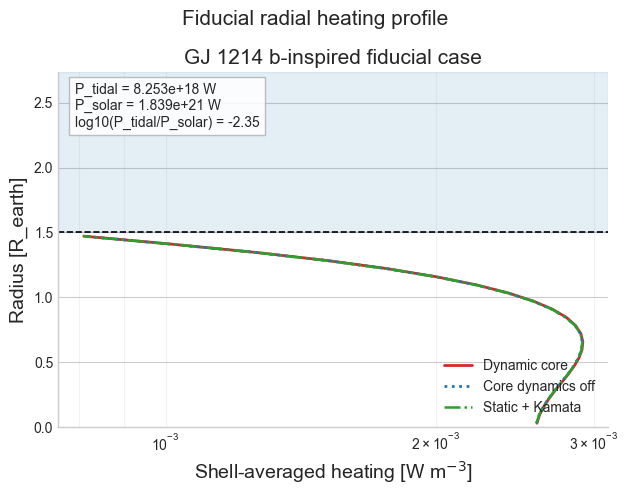

In [8]:
baseline_case = solve_case(
    planet_radius_re=FIDUCIAL_SYSTEM['planet_radius_re'],
    planet_mass_me=FIDUCIAL_SYSTEM['planet_mass_me'],
    period_days=FIDUCIAL_SYSTEM['period_days'],
    core_radius_fraction=0.55,
    host_mass_msun=FIDUCIAL_SYSTEM['host_mass_msun'],
    eccentricity=FIDUCIAL_SYSTEM['eccentricity'],
    label=FIDUCIAL_LABEL,
)

for key in [
    'planet_radius_re',
    'planet_mass_me',
    'period_days',
    'core_radius_fraction',
    'q_eff_abs',
    'total_heating_w',
    'solar_heating_w',
    'tidal_to_solar_ratio',
]:
    print(f'{key:>22s}: {baseline_case[key]}')

plot_extreme_radial_profiles([baseline_case], 'Fiducial radial heating profile');

## Heating-Path Cross-Check

The notebook now compares two heating routes on the same solved radial structure: the stress-strain plus volumetric-heating path used above, and the older `collapse_multilayer_modes` helper used in the older sub-Saturn example notebook. This is the right like-for-like check because any remaining mismatch is then dominated by bookkeeping differences rather than by a different interior model.

A large discrepancy initially appeared because the direct stress-strain route was missing the same frequency normalization that `collapse_multilayer_modes` applies before orbit averaging. Once that normalization is included, the two methods agree at the fiducial point to better than `1e-7` in total heating.

Modern total heating : 7.818e+18 W
Legacy total heating : 7.818e+18 W
Relative difference  : 1.287e-07


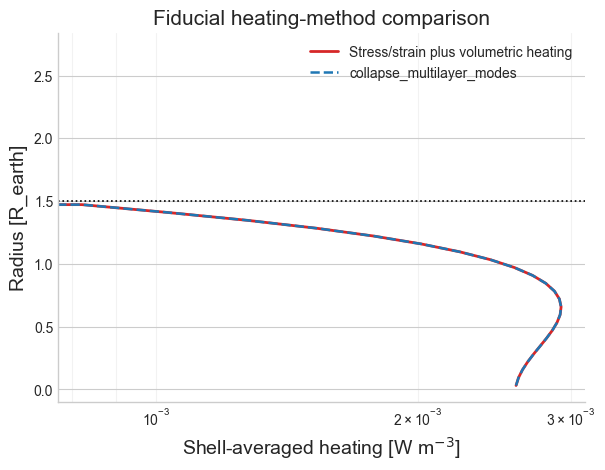

In [9]:
baseline_validation = compare_heating_methods(
    planet_radius_re=baseline_case['planet_radius_re'],
    planet_mass_me=baseline_case['planet_mass_me'],
    period_days=baseline_case['period_days'],
    core_radius_fraction=baseline_case['core_radius_fraction'],
    host_mass_msun=baseline_case['host_mass_msun'],
    eccentricity=baseline_case['eccentricity'],
)

print(f"Modern total heating : {baseline_validation['total_heating_modern_w']:.3e} W")
print(f"Legacy total heating : {baseline_validation['total_heating_legacy_w']:.3e} W")
print(f"Relative difference  : {baseline_validation['relative_difference']:.3e}")

fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.semilogx(
    baseline_validation['profile_modern_wm3'],
    baseline_validation['profile_radius_re'],
    label='Stress/strain plus volumetric heating',
    linewidth=2.0,
    color='tab:red',
)
ax.semilogx(
    baseline_validation['profile_legacy_wm3'],
    baseline_validation['profile_radius_re'],
    label='collapse_multilayer_modes',
    linewidth=1.8,
    linestyle='--',
    color='tab:blue',
)
ax.axhline(baseline_validation['core_radius_re'], color='black', linestyle=':', linewidth=1.2)
ax.set(xlabel=r'Shell-averaged heating [W m$^{-3}$]', ylabel='Radius [R_earth]', title='Fiducial heating-method comparison')
ax.grid(alpha=0.25, which='both', axis='x')
ax.legend(loc='best');

## Radius vs Core-Fraction Sweep

Here the host star and orbital period stay fixed to the GJ 1214 b-inspired system while the planet radius and core-radius fraction are varied. The contour field now shows total tidal power rather than the gas/core partition ratio, while vertical guide lines mark the observed benchmark radii. Green guide lines indicate systems with published or announced JWST observations.

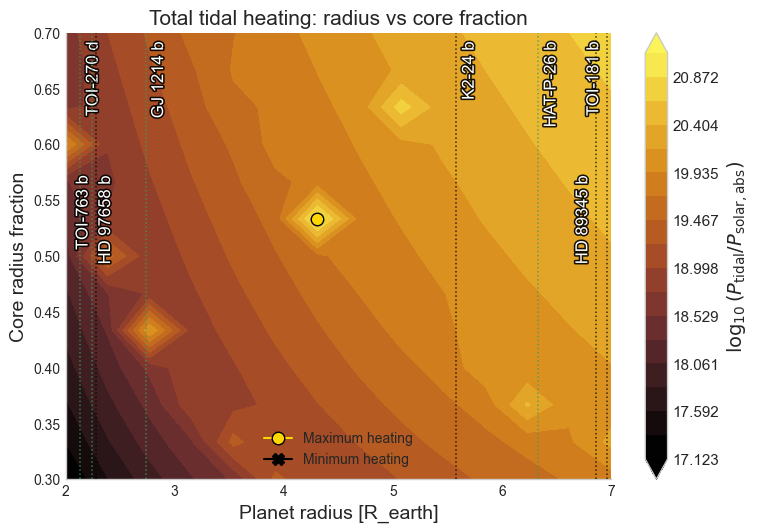

Maximum heating case: R=4.31 R_earth, f_core=0.53 1.279e+21 W
Minimum heating case: R=2.00 R_earth, f_core=0.30 1.328e+17 W


In [10]:
radius_grid_re = np.linspace(2.0, 7.0, 14)
core_fraction_grid = np.linspace(0.3, 0.7, 13)

def build_radius_core_case(radius_re, core_fraction):
    return solve_case(
        planet_radius_re=float(radius_re),
        planet_mass_me=None,
        period_days=FIDUCIAL_SYSTEM['period_days'],
        core_radius_fraction=float(core_fraction),
        host_mass_msun=FIDUCIAL_SYSTEM['host_mass_msun'],
        eccentricity=FIDUCIAL_SYSTEM['eccentricity'],
        label=f'R={radius_re:.2f} R_earth, f_core={core_fraction:.2f}',
    )

total_heating_metric_rc, q_grid_rc, total_heating_grid_rc, case_lookup_rc = evaluate_case_grid(
    radius_grid_re,
    core_fraction_grid,
    build_radius_core_case,
    metric_key='total_heating_w',
)

fig_rc, ax_rc = plot_total_heating_contour(
    radius_grid_re,
    core_fraction_grid,
    total_heating_grid_rc,
    xlabel='Planet radius [R_earth]',
    ylabel='Core radius fraction',
    title='Total tidal heating: radius vs core fraction',
)
add_reference_radius_markers(
    ax_rc,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re.min()), float(radius_grid_re.max())),
)
max_index_rc, min_index_rc = add_extrema_markers(
    ax_rc,
    radius_grid_re,
    core_fraction_grid,
    total_heating_metric_rc,
    maximum_label='Maximum heating',
    minimum_label='Minimum heating',
)
plt.show()

max_case_rc = case_lookup_rc[max_index_rc]
min_case_rc = case_lookup_rc[min_index_rc]
print('Maximum heating case:', max_case_rc['label'], f"{max_case_rc['total_heating_w']:.3e} W")
print('Minimum heating case:', min_case_rc['label'], f"{min_case_rc['total_heating_w']:.3e} W")

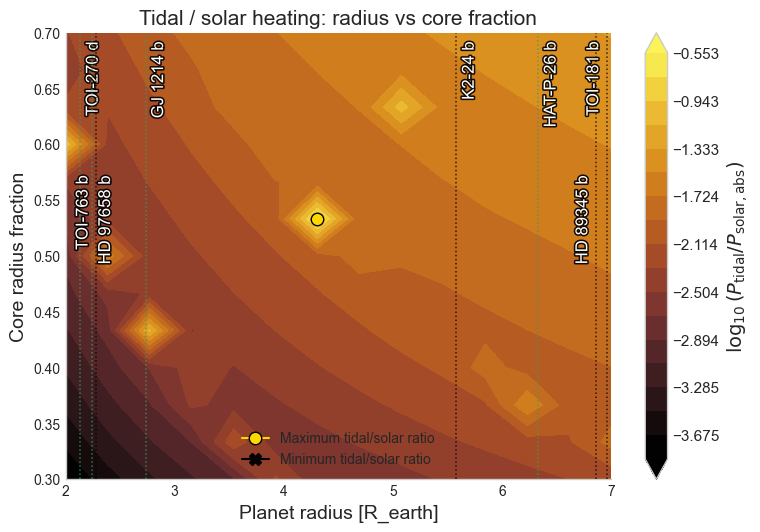

Maximum tidal/solar ratio case: R=4.31 R_earth, f_core=0.53 P_tidal=1.279e+21 W P_tidal/P_solar=2.800e-01
Minimum tidal/solar ratio case: R=2.00 R_earth, f_core=0.30 P_tidal=1.328e+17 W P_tidal/P_solar=1.349e-04


In [11]:
tidal_to_solar_metric_rc, q_grid_rc, total_heating_grid_rc, case_lookup_rc = evaluate_case_grid(
    radius_grid_re,
    core_fraction_grid,
    build_radius_core_case,
    metric_key='tidal_to_solar_ratio',
)

fig_rc, ax_rc = plot_total_heating_contour(
    radius_grid_re,
    core_fraction_grid,
    tidal_to_solar_metric_rc,
    xlabel='Planet radius [R_earth]',
    ylabel='Core radius fraction',
    title='Tidal / solar heating: radius vs core fraction',
)
add_reference_radius_markers(
    ax_rc,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re.min()), float(radius_grid_re.max())),
)
max_index_rc, min_index_rc = add_extrema_markers(
    ax_rc,
    radius_grid_re,
    core_fraction_grid,
    tidal_to_solar_metric_rc,
    maximum_label='Maximum tidal/solar ratio',
    minimum_label='Minimum tidal/solar ratio',
)
plt.show()

max_case_rc = case_lookup_rc[max_index_rc]
min_case_rc = case_lookup_rc[min_index_rc]
print(
    'Maximum tidal/solar ratio case:',
    max_case_rc['label'],
    f"P_tidal={max_case_rc['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={max_case_rc['tidal_to_solar_ratio']:.3e}",
)
print(
    'Minimum tidal/solar ratio case:',
    min_case_rc['label'],
    f"P_tidal={min_case_rc['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={min_case_rc['tidal_to_solar_ratio']:.3e}",
)

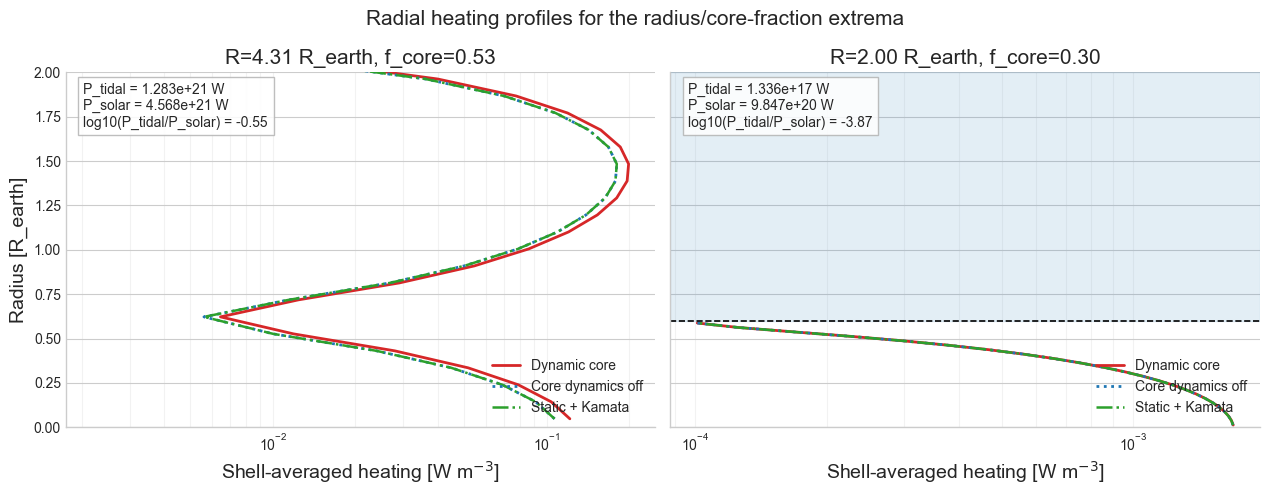

In [12]:
plot_extreme_radial_profiles(
    [max_case_rc, min_case_rc],
    'Radial heating profiles for the radius/core-fraction extrema',
);

## Radius vs Orbital-Period Sweep

This second grid keeps the core-radius fraction fixed at `0.55`, and varies planet radius and orbital period. The contour field again shows total tidal power, and the benchmark markers use green fill for worlds that already have, or are explicitly linked to, JWST observing programs in the recent literature.

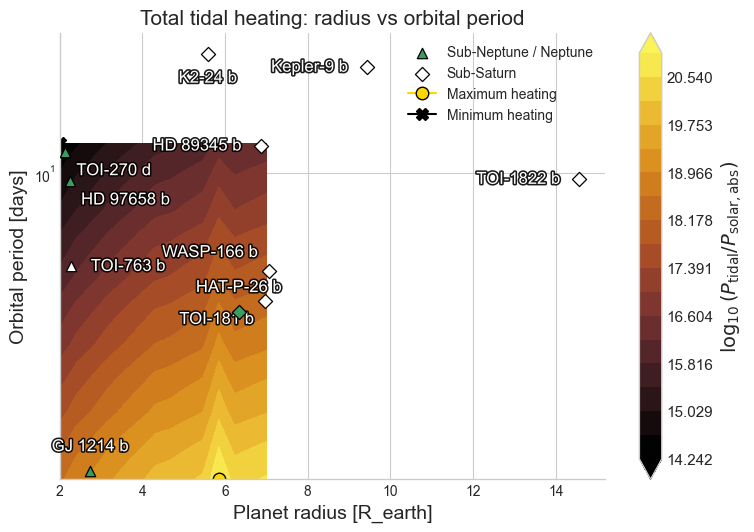

Maximum heating case: R=5.85 R_earth, P=1.50 d 8.590e+20 W
Minimum heating case: R=2.00 R_earth, P=12.00 d 1.744e+14 W


In [13]:
fixed_core_fraction = 0.55
period_grid_days = np.geomspace(1.5, 12.0, 6)

def build_radius_period_case(radius_re, period_days):
    return solve_case(
        planet_radius_re=float(radius_re),
        planet_mass_me=None,
        period_days=float(period_days),
        core_radius_fraction=fixed_core_fraction,
        host_mass_msun=FIDUCIAL_SYSTEM['host_mass_msun'],
        eccentricity=FIDUCIAL_SYSTEM['eccentricity'],
        label=f'R={radius_re:.2f} R_earth, P={period_days:.2f} d',
    )

total_heating_metric_rp, q_grid_rp, total_heating_grid_rp, case_lookup_rp = evaluate_case_grid(
    radius_grid_re,
    period_grid_days,
    build_radius_period_case,
    metric_key='total_heating_w',
)

fig_rp, ax_rp = plot_total_heating_contour(
    radius_grid_re,
    period_grid_days,
    total_heating_grid_rp,
    xlabel='Planet radius [R_earth]',
    ylabel='Orbital period [days]',
    title='Total tidal heating: radius vs orbital period',
)
ax_rp.set_yscale('log')
add_reference_period_markers(ax_rp, OBSERVED_SUB_NEPTUNES)
max_index_rp, min_index_rp = add_extrema_markers(
    ax_rp,
    radius_grid_re,
    period_grid_days,
    total_heating_metric_rp,
    maximum_label='Maximum heating',
    minimum_label='Minimum heating',
)
plt.show()

max_case_rp = case_lookup_rp[max_index_rp]
min_case_rp = case_lookup_rp[min_index_rp]
print('Maximum heating case:', max_case_rp['label'], f"{max_case_rp['total_heating_w']:.3e} W")
print('Minimum heating case:', min_case_rp['label'], f"{min_case_rp['total_heating_w']:.3e} W")

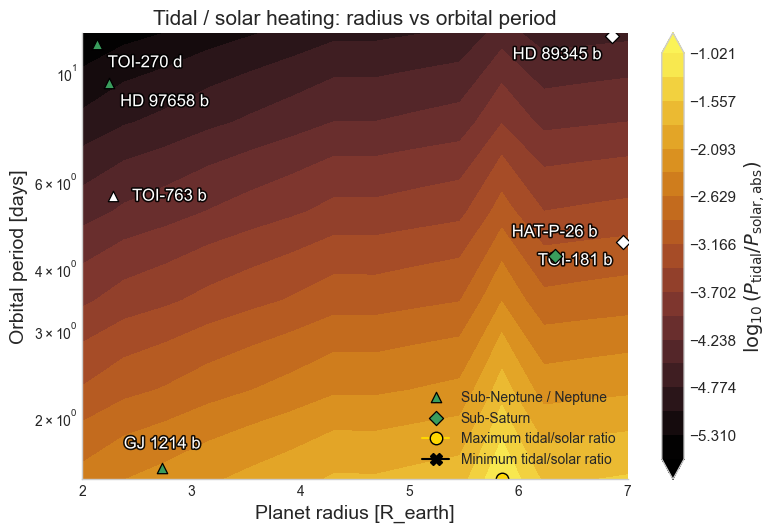

Maximum tidal/solar ratio case: R=5.85 R_earth, P=1.50 d P_tidal=8.590e+20 W P_tidal/P_solar=9.523e-02
Minimum tidal/solar ratio case: R=2.00 R_earth, P=12.00 d P_tidal=1.744e+14 W P_tidal/P_solar=2.644e-06


In [14]:
tidal_to_solar_metric_rp, q_grid_rp, total_heating_grid_rp, case_lookup_rp = evaluate_case_grid(
    radius_grid_re,
    period_grid_days,
    build_radius_period_case,
    metric_key='tidal_to_solar_ratio',
)

fig_rp, ax_rp = plot_total_heating_contour(
    radius_grid_re,
    period_grid_days,
    tidal_to_solar_metric_rp,
    xlabel='Planet radius [R_earth]',
    ylabel='Orbital period [days]',
    title='Tidal / solar heating: radius vs orbital period',
)
ax_rp.set_yscale('log')
add_reference_period_markers(
    ax_rp,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re.min()), float(radius_grid_re.max())),
    y_bounds=(float(period_grid_days.min()), float(period_grid_days.max())),
)
max_index_rp, min_index_rp = add_extrema_markers(
    ax_rp,
    radius_grid_re,
    period_grid_days,
    tidal_to_solar_metric_rp,
    maximum_label='Maximum tidal/solar ratio',
    minimum_label='Minimum tidal/solar ratio',
)
plt.show()

max_case_rp = case_lookup_rp[max_index_rp]
min_case_rp = case_lookup_rp[min_index_rp]
print(
    'Maximum tidal/solar ratio case:',
    max_case_rp['label'],
    f"P_tidal={max_case_rp['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={max_case_rp['tidal_to_solar_ratio']:.3e}",
)
print(
    'Minimum tidal/solar ratio case:',
    min_case_rp['label'],
    f"P_tidal={min_case_rp['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={min_case_rp['tidal_to_solar_ratio']:.3e}",
)

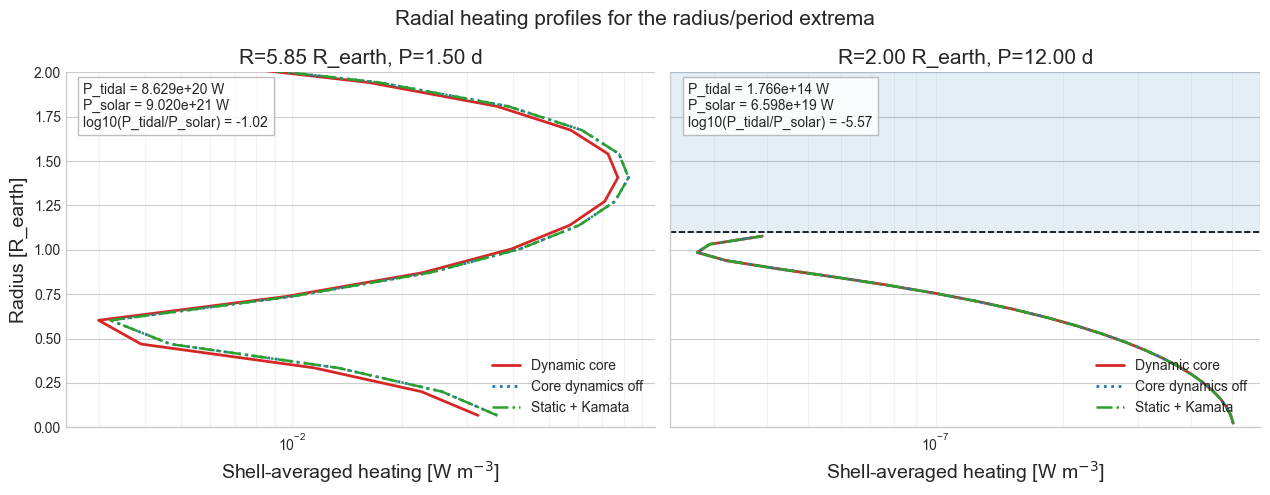

In [15]:
plot_extreme_radial_profiles(
    [max_case_rp, min_case_rp],
    'Radial heating profiles for the radius/period extrema',
);

## Expanded Benchmark Sweeps

The original exploratory grids were tuned for quick turnaround and mainly sampled the sub-Neptune to low-mass sub-Saturn regime. The cells below rerun the two parameter sweeps on a larger radius domain so that WASP-166 b, HAT-P-26 b, TOI-181 b, Kepler-9 b, and TOI-1822 b all lie inside the modeled x-range of the contour plots while preserving the updated total-heating color scale and benchmark styling.

In [16]:
radius_grid_re_expanded = np.linspace(2.0, 15.0, 100)
core_fraction_grid_expanded = np.linspace(0.3, 0.7, 101)
period_grid_days_expanded = np.geomspace(1.5, 24.0, 102)

def build_radius_core_case_expanded(radius_re, core_fraction):
    return solve_case(
        planet_radius_re=float(radius_re),
        planet_mass_me=None,
        period_days=FIDUCIAL_SYSTEM['period_days'],
        core_radius_fraction=float(core_fraction),
        host_mass_msun=FIDUCIAL_SYSTEM['host_mass_msun'],
        eccentricity=FIDUCIAL_SYSTEM['eccentricity'],
        label=f'R={radius_re:.2f} R_earth, f_core={core_fraction:.2f}',
    )

def build_radius_period_case_expanded(radius_re, period_days):
    return solve_case(
        planet_radius_re=float(radius_re),
        planet_mass_me=None,
        period_days=float(period_days),
        core_radius_fraction=fixed_core_fraction,
        host_mass_msun=FIDUCIAL_SYSTEM['host_mass_msun'],
        eccentricity=FIDUCIAL_SYSTEM['eccentricity'],
        label=f'R={radius_re:.2f} R_earth, P={period_days:.2f} d',
    )

total_heating_metric_rc_expanded, q_grid_rc_expanded, total_heating_grid_rc_expanded, case_lookup_rc_expanded = evaluate_case_grid(
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    build_radius_core_case_expanded,
    metric_key='total_heating_w',
)

total_heating_metric_rp_expanded, q_grid_rp_expanded, total_heating_grid_rp_expanded, case_lookup_rp_expanded = evaluate_case_grid(
    radius_grid_re_expanded,
    period_grid_days_expanded,
    build_radius_period_case_expanded,
    metric_key='total_heating_w',
)

print(f'Expanded modeled radius range: {radius_grid_re_expanded.min():.1f} to {radius_grid_re_expanded.max():.1f} R_earth')
print(f'Expanded modeled period range: {period_grid_days_expanded.min():.1f} to {period_grid_days_expanded.max():.1f} days')

Expanded modeled radius range: 2.0 to 15.0 R_earth
Expanded modeled period range: 1.5 to 24.0 days


In [17]:
tidal_to_solar_metric_rc_expanded, q_grid_rc_expanded, total_heating_grid_rc_expanded, case_lookup_rc_expanded = evaluate_case_grid(
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    build_radius_core_case_expanded,
    metric_key='tidal_to_solar_ratio',
)

tidal_to_solar_metric_rp_expanded, q_grid_rp_expanded, total_heating_grid_rp_expanded, case_lookup_rp_expanded = evaluate_case_grid(
    radius_grid_re_expanded,
    period_grid_days_expanded,
    build_radius_period_case_expanded,
    metric_key='tidal_to_solar_ratio',
)

print(f'Expanded modeled radius range: {radius_grid_re_expanded.min():.1f} to {radius_grid_re_expanded.max():.1f} R_earth')
print(f'Expanded modeled period range: {period_grid_days_expanded.min():.1f} to {period_grid_days_expanded.max():.1f} days')

Expanded modeled radius range: 2.0 to 15.0 R_earth
Expanded modeled period range: 1.5 to 24.0 days


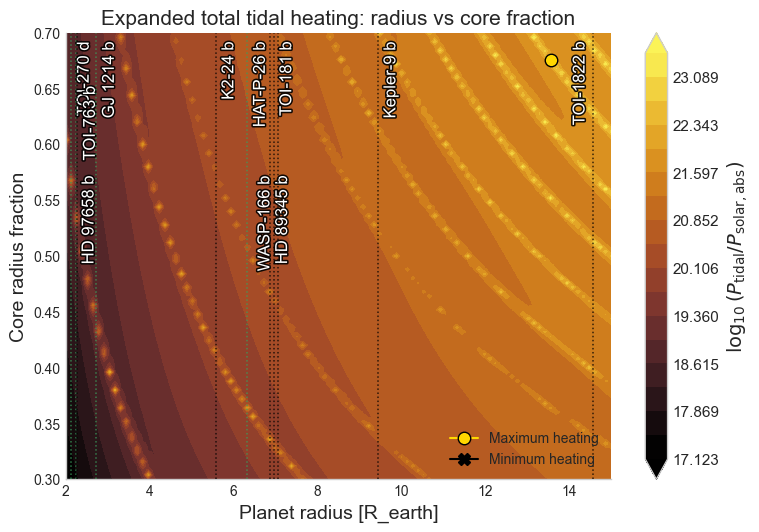

Expanded maximum heating case: R=13.56 R_earth, f_core=0.68 2.895e+23 W
Expanded minimum heating case: R=2.00 R_earth, f_core=0.30 1.328e+17 W


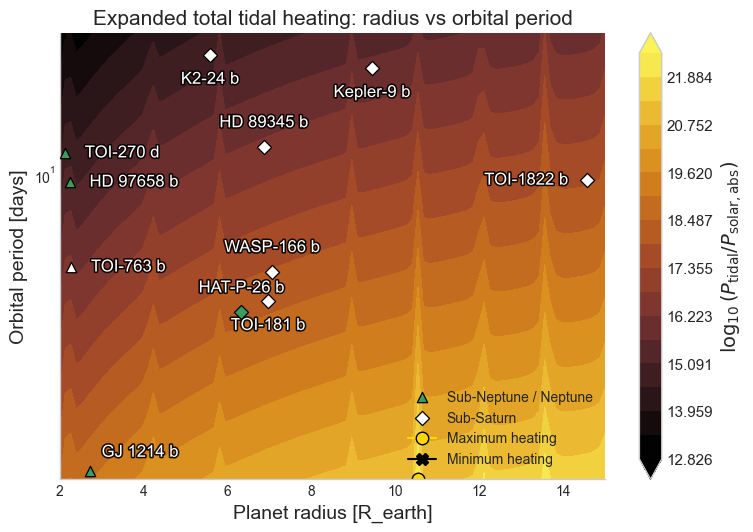

Expanded maximum heating case: R=10.54 R_earth, P=1.50 d 2.819e+22 W
Expanded minimum heating case: R=2.00 R_earth, P=24.00 d 6.704e+12 W


In [18]:
fig_rc_expanded, ax_rc_expanded = plot_total_heating_contour(
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    total_heating_grid_rc_expanded,
    xlabel='Planet radius [R_earth]',
    ylabel='Core radius fraction',
    title='Expanded total tidal heating: radius vs core fraction',
)
add_reference_radius_markers(
    ax_rc_expanded,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re_expanded.min()), float(radius_grid_re_expanded.max())),
)
max_index_rc_expanded, min_index_rc_expanded = add_extrema_markers(
    ax_rc_expanded,
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    total_heating_metric_rc_expanded,
    maximum_label='Maximum heating',
    minimum_label='Minimum heating',
)
plt.show()

max_case_rc_expanded = case_lookup_rc_expanded[max_index_rc_expanded]
min_case_rc_expanded = case_lookup_rc_expanded[min_index_rc_expanded]
print('Expanded maximum heating case:', max_case_rc_expanded['label'], f"{max_case_rc_expanded['total_heating_w']:.3e} W")
print('Expanded minimum heating case:', min_case_rc_expanded['label'], f"{min_case_rc_expanded['total_heating_w']:.3e} W")

fig_rp_expanded, ax_rp_expanded = plot_total_heating_contour(
    radius_grid_re_expanded,
    period_grid_days_expanded,
    total_heating_grid_rp_expanded,
    xlabel='Planet radius [R_earth]',
    ylabel='Orbital period [days]',
    title='Expanded total tidal heating: radius vs orbital period',
)
ax_rp_expanded.set_yscale('log')
add_reference_period_markers(
    ax_rp_expanded,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re_expanded.min()), float(radius_grid_re_expanded.max())),
    y_bounds=(float(period_grid_days_expanded.min()), float(period_grid_days_expanded.max())),
)
max_index_rp_expanded, min_index_rp_expanded = add_extrema_markers(
    ax_rp_expanded,
    radius_grid_re_expanded,
    period_grid_days_expanded,
    total_heating_metric_rp_expanded,
    maximum_label='Maximum heating',
    minimum_label='Minimum heating',
)
plt.show()

max_case_rp_expanded = case_lookup_rp_expanded[max_index_rp_expanded]
min_case_rp_expanded = case_lookup_rp_expanded[min_index_rp_expanded]
print('Expanded maximum heating case:', max_case_rp_expanded['label'], f"{max_case_rp_expanded['total_heating_w']:.3e} W")
print('Expanded minimum heating case:', min_case_rp_expanded['label'], f"{min_case_rp_expanded['total_heating_w']:.3e} W")

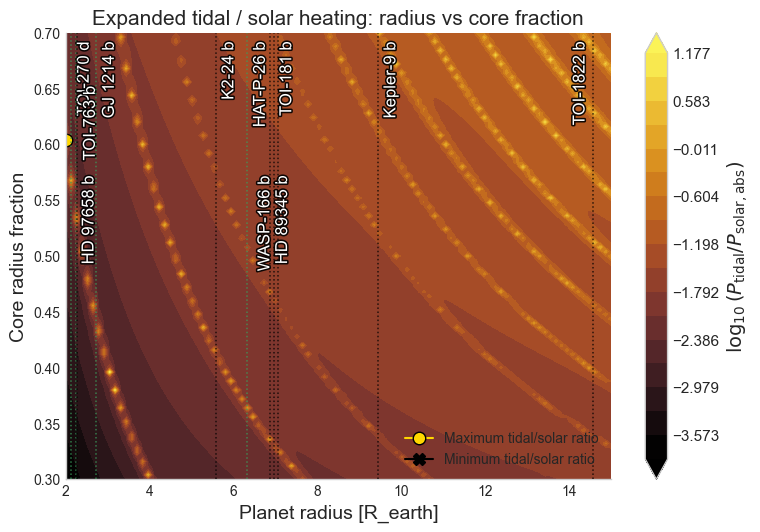

Expanded maximum tidal/solar ratio case: R=2.00 R_earth, f_core=0.60 P_tidal=1.480e+22 W P_tidal/P_solar=1.503e+01
Expanded minimum tidal/solar ratio case: R=2.00 R_earth, f_core=0.30 P_tidal=1.328e+17 W P_tidal/P_solar=1.349e-04


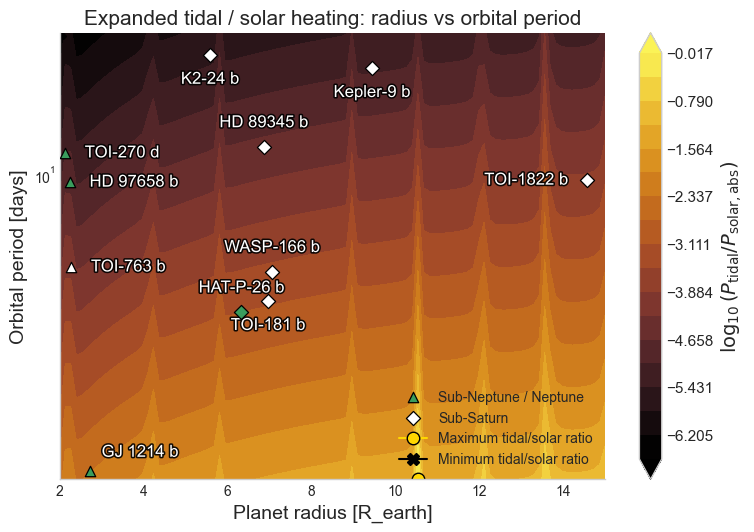

Expanded maximum tidal/solar ratio case: R=10.54 R_earth, P=1.50 d P_tidal=2.819e+22 W P_tidal/P_solar=9.624e-01
Expanded minimum tidal/solar ratio case: R=2.00 R_earth, P=24.00 d P_tidal=6.704e+12 W P_tidal/P_solar=2.560e-07


In [19]:
fig_rc_expanded, ax_rc_expanded = plot_total_heating_contour(
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    tidal_to_solar_metric_rc_expanded,
    xlabel='Planet radius [R_earth]',
    ylabel='Core radius fraction',
    title='Expanded tidal / solar heating: radius vs core fraction',
)
add_reference_radius_markers(
    ax_rc_expanded,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re_expanded.min()), float(radius_grid_re_expanded.max())),
)
max_index_rc_expanded, min_index_rc_expanded = add_extrema_markers(
    ax_rc_expanded,
    radius_grid_re_expanded,
    core_fraction_grid_expanded,
    tidal_to_solar_metric_rc_expanded,
    maximum_label='Maximum tidal/solar ratio',
    minimum_label='Minimum tidal/solar ratio',
)
plt.show()

max_case_rc_expanded = case_lookup_rc_expanded[max_index_rc_expanded]
min_case_rc_expanded = case_lookup_rc_expanded[min_index_rc_expanded]
print(
    'Expanded maximum tidal/solar ratio case:',
    max_case_rc_expanded['label'],
    f"P_tidal={max_case_rc_expanded['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={max_case_rc_expanded['tidal_to_solar_ratio']:.3e}",
)
print(
    'Expanded minimum tidal/solar ratio case:',
    min_case_rc_expanded['label'],
    f"P_tidal={min_case_rc_expanded['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={min_case_rc_expanded['tidal_to_solar_ratio']:.3e}",
)

fig_rp_expanded, ax_rp_expanded = plot_total_heating_contour(
    radius_grid_re_expanded,
    period_grid_days_expanded,
    tidal_to_solar_metric_rp_expanded,
    xlabel='Planet radius [R_earth]',
    ylabel='Orbital period [days]',
    title='Expanded tidal / solar heating: radius vs orbital period',
)
ax_rp_expanded.set_yscale('log')
add_reference_period_markers(
    ax_rp_expanded,
    OBSERVED_SUB_NEPTUNES,
    x_bounds=(float(radius_grid_re_expanded.min()), float(radius_grid_re_expanded.max())),
    y_bounds=(float(period_grid_days_expanded.min()), float(period_grid_days_expanded.max())),
)
max_index_rp_expanded, min_index_rp_expanded = add_extrema_markers(
    ax_rp_expanded,
    radius_grid_re_expanded,
    period_grid_days_expanded,
    tidal_to_solar_metric_rp_expanded,
    maximum_label='Maximum tidal/solar ratio',
    minimum_label='Minimum tidal/solar ratio',
)
plt.show()

max_case_rp_expanded = case_lookup_rp_expanded[max_index_rp_expanded]
min_case_rp_expanded = case_lookup_rp_expanded[min_index_rp_expanded]
print(
    'Expanded maximum tidal/solar ratio case:',
    max_case_rp_expanded['label'],
    f"P_tidal={max_case_rp_expanded['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={max_case_rp_expanded['tidal_to_solar_ratio']:.3e}",
)
print(
    'Expanded minimum tidal/solar ratio case:',
    min_case_rp_expanded['label'],
    f"P_tidal={min_case_rp_expanded['total_heating_w']:.3e} W",
    f"P_tidal/P_solar={min_case_rp_expanded['tidal_to_solar_ratio']:.3e}",
)